# Class Prediction
**Background**  
- 【背景】カフェチェーンの需要予測とCRM最適化
  - あるカフェチェーン。10店舗（Store A〜J）、1万人規模のアプリ会員を持つ
  - 「ラテ」の販促キャンペーンを本部にて検討中。的確な需要予測と合理的説明をもって店舗の支持を得ながら進行したい
- 【課題】利益の最大化、店舗オペレーションの最適化、本部提案の納得感
  - 過去の失敗経験: 昨年の同様企画では予測精度が不十分で、店舗の理解も得られず、期待を下回る結果だった
  - 予算の制約: 以前にも増して本部販促費の投資対効果が注視されており、次回施策のためにも予測精度は担保したい
  - 店舗の裁量: 発注やシフト作成は店舗判断のため、納得感ある説明および行動しやすい判断材料が求められている
  
- 【問題の設定】分類予測
  - クーポン配布という施策内容に反応しやすい顧客層を特定することでROIを最大化しつつ、予測の理由を解釈しやすい判断材料を提供する
- 【解法】LGBM, Tabular DLなど
（仮案）
1. LightGBMで素早く初動回答することで、関係者合意を取り付けやすい土壌を作りやすい企画進行を支援する
1. GBDTやTabular DLなども使うことで、説明可能性や予測精度を検証
1. hoge

- 環境
  - Google Colab利用

In [116]:
# import
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt
import seaborn as sns

# from causalimpact import CausalImpact
# from prophet import Prophet
# import pymc as pm
# import arviz as az

import sklearn
import lightgbm as lgb
import shap
# import xgboost as xgb


# create datetime
print("Created(JST)", pd.Timestamp.now(tz="Asia/Tokyo").strftime("%Y-%m-%d %H:%M:%S"))

# version
import sys; print("Python", sys.version)
print("pandas", pd.__version__)
print("numpy", np.__version__)
print("matplotlib", plt.matplotlib.__version__)
print("seaborn", sns.__version__)
# import causalimpact; print("causalimpact", causalimpact.__version__)
# import prophet; print("prophet", prophet.__version__)
# print("pymc", pm.__version__)
# print("arviz", az.__version__)

print("scikit-learn", sklearn.__version__)
print("lightgbm", lgb.__version__)
import shap; print("shap", shap.__version__)
# print("xgboost", xgb.__version__)

Created(JST) 2026-04-17 17:58:24
Python 3.10.20 | packaged by conda-forge | (main, Mar  5 2026, 17:06:34) [Clang 19.1.7 ]
pandas 1.5.3
numpy 1.23.5
matplotlib 3.7.4
seaborn 0.12.2
scikit-learn 1.2.2
lightgbm 4.6.0
shap 0.49.1


In [2]:
# # サンプルのdataframeを生成する
import string

# --- 基本設定 ---
# start_date = pd.to_datetime("2025-09-01")  # 開始日
# n_days = 92  # 3ヶ月分くらいある設定にする
# n_stores = 10  # 10店舗くらいある設定にする
# n_customers = 10000  # 顧客は10000人くらい


def generate_cafe_data_v3(n_days=92, n_stores=10, n_customers=10000):
    np.random.seed(42)
    
    # --- 1. マスタ作成 ---
    store_ids = [f'Store_{string.ascii_uppercase[i]}' for i in range(n_stores)]
    dates = pd.date_range(start='2025-09-01', periods=n_days)
    
    # 顧客マスタ（10,000人）
    chars = list(string.ascii_lowercase + string.digits)
    unique_customer_ids = [''.join(np.random.choice(chars, 8)) for _ in range(n_customers)]
    customer_master = pd.DataFrame({
        'customer_id': unique_customer_ids,
        # 会員歴（年）: 指数分布っぽく（新しい人の方が多い）
        'membership_years': np.random.exponential(2, n_customers).clip(0.5, 10),
        # 過去のラテ購入率（潜在的な好みの代理指標: 存在しなくて自前で用意、定義すべきような指標かも）0.1〜0.9の間で分布
        'past_latte_ratio': np.random.beta(2, 5, n_customers),
        # 過去のクーポン利用率（感度の代理指標）
        'past_coupon_usage_rate': np.random.beta(1, 3, n_customers)
    })

    # 店舗×日付単位の外部環境マスタを作成
    env_data = []
    for d in dates:
        is_raining = np.random.binomial(1, 0.20)  # 20%の確率で雨の日
        is_weekend = 1 if d.dayofweek >= 5 else 0
        daily_temp_base = 15 + (d.day % 5)  # 15〜19度
        
        for s in store_ids:
            env_data.append({
                'date': d,
                'store_id': s,
                'is_raining': is_raining,
                'is_weekend': is_weekend,
                'current_temp': daily_temp_base + np.random.normal(0, 0.5),
                # わざと役立ちそうにない特徴量を含める
                'station_congestion_index': np.random.normal(100, 15),  # 各店舗の最寄駅のその日の混雑度
                'daily_staffing_cost': np.random.randint(50000, 150000)  # 各店舗のその日の人件費
            })
    df_env = pd.DataFrame(env_data)

    # --- 2. 来店イベントの生成 ---
    # 各顧客が期間中に合計何回来店するか（ポアソン分布でバラつきを出す）
    # customer_master['total_visits'] = np.random.poisson(8, n_customers)  # 平均8回来店
    avg_visits_per_7days = 3  # 7日で平均3回来店する設定
    lambda_visits = (avg_visits_per_7days / 7) * n_days  # 1日あたりの来店回数×全期間=期間中の合計来店回数
    customer_master['total_visits'] = np.random.poisson(lambda_visits, n_customers)

    all_visits = []
    for _, row in customer_master.iterrows():
        if row['total_visits'] == 0: continue
        
        # 来店回数分だけ行を生成
        for _ in range(row['total_visits']):
            all_visits.append({
                'customer_id': row['customer_id'],
                'date': np.random.choice(dates),  # ランダムな日に来店
                'store_id': np.random.choice(store_ids)  # ランダムな店に来店
            })
    
    df_main = pd.DataFrame(all_visits)
    # マスタとマージ
    df = df_main.merge(customer_master.drop(columns='total_visits'), on='customer_id')
    df = df.merge(df_env, on=['date', 'store_id'])

    # --- 3. 購買ロジックの適用 ---
    # 店舗ごとの地力（固定効果）
    store_bias = {s: np.random.normal(0, 0.8) for s in store_ids}
    
    # 処置（クーポン配布）は来店ごとに50%の確率
    df['is_treatment'] = np.random.binomial(1, 0.5, len(df))
    # わざと役立ちそうにない特徴量を含める: アプリPV（顧客×来店ごとにランダム）
    df['app_total_pv'] = np.random.poisson(5, len(df))

    # 現実には観測できない真の値（購買ロジック: 不要な特徴量は含めない）
    logit = (
        -3.0
        + (df['past_latte_ratio'] * 7.0)  # 強烈に効く
        + (df['is_treatment'] * df['past_coupon_usage_rate'] * 6.0)  # クーポンも効く
        + df['store_id'].map(store_bias)  # 店舗バイアスある
        + (df['is_weekend'] * 1.0)  # 週末はラテ売れやすい
        - (df['is_raining'] * 2.0)  # 雨だとはラテ売れにくい
    )
    
    prob = 1 / (1 + np.exp(-logit))
    df['is_purchased'] = np.random.binomial(1, prob)
    
    # わざと欠損値を含める
    df.loc[df.sample(frac=0.03).index, 'current_temp'] = np.nan
    # わざとobject型にする
    df['past_latte_ratio'] = df['past_latte_ratio'].astype(object)
    # わざと?を混入させる
    dirty_idx = df.sample(frac=0.005).index
    df.loc[dirty_idx, 'past_latte_ratio'] = '?'
    # 過去のクーポン利用率を一部不明（新規やデータ不備など）にする
    df.loc[df.sample(frac=0.1).index, 'past_coupon_usage_rate'] = np.nan

    # return df.sort_values(['date', 'store_id']).reset_index(drop=True)
    return df  # わざとソートせずに出力

df1 = generate_cafe_data_v3()

In [3]:
# 土日祝日フラグを追加する

# 1. 祝日データの作成
import jpholiday

# df['ds'] から期間の開始日と終了日を取得
start = df1['date'].min()
end = df1['date'].max()
# または手打ち
# start = pd.to_datetime("2025-07-01")
# end = pd.to_datetime("2025-07-31")

# 年をまたぐ可能性考えて、ユニークな年を取得
years = df1['date'].dt.year.unique()

holidays_list = []
for y in years:
    for date, name in jpholiday.year_holidays(int(y)):
        # データの期間内に入っている祝日だけ追加
        if start.date() <= date <= end.date():
            holidays_list.append({'ds': pd.to_datetime(date), 'holiday': name})

holidays_df = pd.DataFrame(holidays_list)
holidays_df

,ds,holiday
0,2025-09-15,敬老の日
1,2025-09-23,秋分の日
2,2025-10-13,スポーツの日
3,2025-11-03,文化の日
4,2025-11-23,勤労感謝の日
5,2025-11-24,勤労感謝の日 振替休日


In [4]:
# 2. 土日フラグを立てておいて（5:土曜日, 6:日曜日）
df1["is_holiday"] = df1["date"].dt.weekday.apply(lambda x: 1 if x >= 5 else 0)

# 3. holidays_df に含まれる日付（平日祝日）を 1 に更新する
# dt.normalize() を使うと時刻が 00:00:00 に揃うので比較が確実
holiday_dates = holidays_df['ds'].dt.normalize()
df1.loc[df1['date'].dt.normalize().isin(holiday_dates), "is_holiday"] = 1

In [5]:
# past_latte_ratioやpast_coupon_usage_rateがずっと同じ状態でデータ生成されちゃうので、これを店舗*customer_idごとに時点を経るたびにちゃんと変わるようなのに変えたいな

## speedy check
- データセットの中身、行列数、データ型は意図通りか、混入物がないか確認
- データの不完全さを素早く直感的に把握し、データのクリーニング方法などを適切に判断する
- この段階ではデータをキレイにするところがゴール（欠損値NaNをどうするかは後で）

In [6]:
# 中身をざっと眺める（カラム名と中身が一致してそうか）
print(df1.head())
# print(df1.sample(5))
# print(df1.tail())

  customer_id       date store_id  membership_years past_latte_ratio  \
0    2ohuswkk 2025-10-04  Store_A          0.500000         0.117972   
1    5d3wo29m 2025-10-04  Store_A          0.500000         0.186578   
2    no4acpwk 2025-10-04  Store_A          2.774268         0.387087   
3    z1wnxbzn 2025-10-04  Store_A          0.641568         0.301709   
4    zcfeewi8 2025-10-04  Store_A          2.566660         0.265289   

   past_coupon_usage_rate  is_raining  is_weekend  current_temp  \
0                0.129511           0           1     19.734029   
1                0.233599           0           1           NaN   
2                0.258157           0           1     19.734029   
3                0.063614           0           1     19.734029   
4                0.311353           0           1     19.734029   

   station_congestion_index  daily_staffing_cost  is_treatment  app_total_pv  \
0                 90.909776               110125             0             8   
1   

In [7]:
# データ構造（行列数）を把握する
print(df1.shape)

# データ型の把握
print(df1.info())

(394899, 15)
<class 'pandas.core.frame.DataFrame'>
Int64Index: 394899 entries, 0 to 394898
Data columns (total 15 columns):
 #   Column                    Non-Null Count   Dtype         
---  ------                    --------------   -----         
 0   customer_id               394899 non-null  object        
 1   date                      394899 non-null  datetime64[ns]
 2   store_id                  394899 non-null  object        
 3   membership_years          394899 non-null  float64       
 4   past_latte_ratio          394899 non-null  object        
 5   past_coupon_usage_rate    355409 non-null  float64       
 6   is_raining                394899 non-null  int64         
 7   is_weekend                394899 non-null  int64         
 8   current_temp              383052 non-null  float64       
 9   station_congestion_index  394899 non-null  float64       
 10  daily_staffing_cost       394899 non-null  int64         
 11  is_treatment              394899 non-null  int64    

In [8]:
# データ型の把握（数値型のみ）
df1.select_dtypes(include=["number"]).info()

# 数値型扱いになっているが、カテゴリ変数として扱いたいカラムが混ざっていないか？
# 例えば、識別子やカテゴリ変数を思わせるid/code/typeといった文字列を含むカラム名だったり、ユニーク数が極端に少ないカラムなど
# 例えば、yyyymmddが年/月/日に分かれて格納されてるなど、hh時間帯など

<class 'pandas.core.frame.DataFrame'>
Int64Index: 394899 entries, 0 to 394898
Data columns (total 11 columns):
 #   Column                    Non-Null Count   Dtype  
---  ------                    --------------   -----  
 0   membership_years          394899 non-null  float64
 1   past_coupon_usage_rate    355409 non-null  float64
 2   is_raining                394899 non-null  int64  
 3   is_weekend                394899 non-null  int64  
 4   current_temp              383052 non-null  float64
 5   station_congestion_index  394899 non-null  float64
 6   daily_staffing_cost       394899 non-null  int64  
 7   is_treatment              394899 non-null  int64  
 8   app_total_pv              394899 non-null  int64  
 9   is_purchased              394899 non-null  int64  
 10  is_holiday                394899 non-null  int64  
dtypes: float64(4), int64(7)
memory usage: 44.2 MB


In [9]:
def suggest_categorical_columns(df):
    """
    数値型だけど、実はカテゴリかもしれないカラムを提案するにゃん。
    """
    suspicious_cols = []
    for col in df.select_dtypes(include=['number']).columns:
        # 1. カラム名に "id", "code", "type", "weekday" などが入っている
        # 2. あるいは、ユニークな値の数が極端に少ない（例：データ量の1%未満など）
        unique_count = df[col].nunique()
        if any(keyword in col.lower() for keyword in ["id", "code", "type", "day", "flag"]):
            suspicious_cols.append((col, unique_count))
            
    if suspicious_cols:
        print("💡 以下の数値カラムは、カテゴリ型に変えたほうがいいかもしれないにゃん：")
        for col, count in suspicious_cols:
            print(f"   ∟ {col} (ユニーク値: {count}件)")
    else:
        print("✅ 数値カラムにIDっぽいものは見当たらないにゃん。")

# 実行
suggest_categorical_columns(df1)

💡 以下の数値カラムは、カテゴリ型に変えたほうがいいかもしれないにゃん：
   ∟ is_holiday (ユニーク値: 2件)


In [10]:
# カテゴリ型に変更するか検討のために、要約統計量（範囲、分布、偏り、外れ値など）を把握
df1['is_holiday'].describe()

count    394899.000000
mean          0.336132
std           0.472385
min           0.000000
25%           0.000000
50%           0.000000
75%           1.000000
max           1.000000
Name: is_holiday, dtype: float64

In [11]:
# カテゴリ型に変更するか検討のために、種別を把握
df1['is_holiday'].unique()

array([1, 0])

In [12]:
# 数値型データのうち、カテゴリ変数にしたいものを型変換する

# 一度文字列にしてからcategory型にする
# df1["value_id"] = df1["value_id"].astype(str).astype("category")

# 順序に意味があるカテゴリ変数にしたい場合（満足度 high/mid/lowや曜日など）
# 並び順を指定してcategory型にする
# weekday_order = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]
# df1["weekday"] = pd.Categorical(df1["weekday"].astype(str), categories=weekday_order, ordered=True)
# 特徴量として使う際に、モデルがこの並び順でなんらか傾向があるかも？と並び順の情報を保持したまま学習してくれる

In [13]:
# 数値型データのうち、例えばyyyymmddが年/月/日に分かれて格納されてるのを、束ねてdatetimeに型変換する

# カラム名が 'year', 'month', 'day' ならこれで
# df1['date'] = pd.to_datetime(df1[['year', 'month', 'day']])
# あるいは辞書形式で指定する
# df1['date'] = pd.to_datetime({'year': df1['yyyy'], 'month': df1['mm'], 'day': df1['dd']})

In [14]:
# データ型の把握（数値型以外のだけ）
df1.select_dtypes(exclude=["number"]).info()

# 数値データのカラムは数値型になってるか？
# 日付データのカラムはdatetime型になってるか？

<class 'pandas.core.frame.DataFrame'>
Int64Index: 394899 entries, 0 to 394898
Data columns (total 4 columns):
 #   Column            Non-Null Count   Dtype         
---  ------            --------------   -----         
 0   customer_id       394899 non-null  object        
 1   date              394899 non-null  datetime64[ns]
 2   store_id          394899 non-null  object        
 3   past_latte_ratio  394899 non-null  object        
dtypes: datetime64[ns](1), object(3)
memory usage: 23.1+ MB


## check numeric

In [15]:
# object型カラムの中身を把握
# 数値型であって欲しいのに、object型になっているカラムへの混入物を目視のうえで無くしたい意図

# チェックしたいカラムをリストアップ（object型のうち、そうであって欲しくないカラムのみ）
target_numeric_cols = ['membership_years', 'past_latte_ratio', 'current_temp']

In [16]:
# # 自作関数の外部スクリプトをimport
# !wget https://raw.githubusercontent.com/sasasakaz/utility/main/data_checks/data_inspection.py
# import data_inspection
# data_inspection.scan_numeric_columns(df1, target_numeric_cols)

In [17]:

def scan_numeric_columns(df, target_cols):
    """
    数値型にしたいカラムをスキャンし、数値以外の文字が混ざっていないかチェックするにゃん。
    """
    # 存在するカラム、かつまだobject型のものだけを抽出
    # 数値型に変換済みのカラムがtarget_colsに含まれていた場合に不要なチェックを回避するフィルタ
    check_cols = [c for c in target_cols if c in df.columns and df[c].dtype == 'object']

    if not check_cols:
        print("✅ 対象のカラムはすべて数値型になってるにゃん！")
        return

    print("--- 🔍 数値列のobject混入チェック ---")
    for col in check_cols:
        # 数値に変換を試みる（数値にできないエラーのぶんはNaNになる）
        converted = pd.to_numeric(df[col], errors='coerce')
        # もともとNaNではなく、数値変換によって新たにNaNになった値（＝混入物）を特定
        # 混入物が入っている行だけを抽出
        non_numeric_rows = df.loc[converted.isna() & df[col].notna(), col]
        
        if not non_numeric_rows.empty:
            total_count = len(df)
            counts = non_numeric_rows.value_counts()
            total_non_numeric = counts.sum()
            rate = (total_non_numeric / total_count) * 100
            
            print(f"⚠️ {col}")
            print(f"   ∟ 総数: {total_count:,} 件")
            print(f"   ∟ 数値以外のデータ: {total_non_numeric:,} 件 ({rate:.2f} %)")
            print(f"   ∟ 詳細: ")
            for val, cnt in counts.items():
                print(f"      - '{val}': {cnt:,} 件")
            print("-" * 35)
        else:            
            print(f"✅ {col} -> すべて数値に変換可能だにゃん！")

In [18]:
scan_numeric_columns(df1, target_numeric_cols)

--- 🔍 数値列のobject混入チェック ---
⚠️ past_latte_ratio
   ∟ 総数: 394,899 件
   ∟ 数値以外のデータ: 1,974 件 (0.50 %)
   ∟ 詳細: 
      - '?': 1,974 件
-----------------------------------


In [19]:
# 混入物の処理方法案

# # 不要な文字列は混入しているが、少数で影響軽微と許容できる、あるいはスピード優先したい場合
# # 数値にできない文字列は強制的にNaN（欠損値）に置換する（NaNを含むので強制的にfloat64型になる）
df1['past_latte_ratio'] = pd.to_numeric(df1['past_latte_ratio'], errors='coerce')

# # この文字は0にしたい、この文字は欠損値扱いにしたいなどの明確な根拠、意思がある場合
# # replaceで明示的に特定の文字を、それぞれ置換してからastype
# df1['value1'] = df1['value1'].replace({'?': 0, 'Unknown': np.nan}).astype(float)  # ?は0に、UnknownはNaNに置換
# df1["value1"] = df1["value1"].replace(["", "?"], np.nan)  # 空白と?はNaNに置換

# "1,200円"のように数字に関連する余計な文字がくっついている場合
# 正規表現で数字以外を削ぎ落とす（数字、小数点、マイナス記号以外を全部消す）
# df1['value1'] = df1['value1'].str.replace(r'[^0-9.-]', '', regex=True).astype(float)

In [20]:
# （混入物はなく全て数値情報のみだったが）object型になっているカラムを、数値型に変換する
# df1["value1"] = df1["value1"].astype(float)

## check datetime
- 時点情報がdatetimeじゃないのはいろいろ不都合
- 日付列がdatetime型になっていない原因を把握する

In [21]:
# チェックしたい日付列をリストアップ
target_datetime_cols = ['date']

In [22]:

def scan_datetime_columns(df, target_cols):
    """
    datetime型にしたいカラムをスキャンし、日付として読み取れない文字を特定するにゃん。
    """
    # 存在するカラム、かつまだobject型のものだけを抽出
    # datetime型に変換済みのカラムがtarget_date_colsに含まれていた場合に不要なチェックを回避するフィルタ
    check_cols = [c for c in target_cols if c in df.columns and df[c].dtype == 'object']

    if not check_cols:
        print("✅ 対象のカラムはすべてdatetime型（または変換不要）だにゃん!")
        return

    print("--- 🔍 日付列のフォーマット不備チェック ---")
    for col in check_cols:
        # 日付型に変換を試みる（日付にできないエラーのぶんはNaNになる）
        converted = pd.to_datetime(df[col], errors='coerce')
        # もともとNaNではなく、日付変換によって新たにNaNになった値（＝混入物）を特定
        invalid_date_rows = df.loc[converted.isna() & df[col].notna(), col]
        
        if not invalid_date_rows.empty:
            total_count = len(df)
            counts = invalid_date_rows.value_counts()
            total_invalid = counts.sum()
            rate = (total_invalid / total_count) * 100
            
            print(f"⚠️ {col}")
            print(f"   ∟ 総数: {total_count:,} 件")
            print(f"   ∟ 日付にできないデータ: {total_invalid:,} 件 ({rate:.2f} %)")
            print(f"   ∟ 詳細: ")
            for val, cnt in counts.items():
                print(f"      - '{val}': {cnt:,} 件")
            print("-" * 35)
        else:            
            print(f"✅ {col} -> すべての日付が正しく変換可能だにゃん!")

In [23]:
scan_datetime_columns(df1, target_datetime_cols)

✅ 対象のカラムはすべてdatetime型（または変換不要）だにゃん!


In [24]:
# # object型の日付データをdatetime型に変換する

# # 全カラムが明らかに日付情報のみであることが確実な場合に（文字列混入していると実行エラーになる）
# df1["date"] = pd.to_datetime(df1["date"])
# df1["date"] = pd.to_datetime(df1["date"].astype(str))　　# 数値型（20250701）の場合は一度文字列にしてから変換

# # 不要な文字列が混入してるとわかってるが、少数で影響軽微と許容できる、あるいはスピード優先したい場合
# # 日付にできない文字列は強制的にNaN（欠損値）に置換したうえで、削除する
# df1['date'] = pd.to_datetime(df1['date'], errors='coerce')
# before_count = len(df1)  # 日付がNaNの行を削除する前の行数
# df1 = df1.dropna(subset=['date']).reset_index(drop=True)  # 日付がNaNの行を削除してインデックスを振り直す
# after_count = len(df1)  # 日付がNaNの行を削除した後の行数
# print(f"日付不備で {before_count - after_count:,} 件のデータをドロップしたにゃん")

# 日付データのカラムの中身がもっと変で複雑な場合は、適宜加工してキレイに変換しよう（ここでは省略）

## check object
- データの範囲、分布、偏り、外れ値、頻度などを確認

In [25]:
# object型の要約統計量（頻度やユニーク数など）を把握
df1.describe(exclude='number')

/var/folders/ng/w2vmc_ks6jzfd1prm5s8p54w0000gn/T/ipykernel_1552/3361786825.py:2: FutureWarning: Treating datetime data as categorical rather than numeric in `.describe` is deprecated and will be removed in a future version of pandas. Specify `datetime_is_numeric=True` to silence this warning and adopt the future behavior now.
  df1.describe(exclude='number')


,customer_id,date,store_id
count,394899,394899,394899
unique,10000,92,10
top,eonrlc6d,2025-09-20 00:00:00,Store_E
freq,65,4444,39826
first,NaN,2025-09-01 00:00:00,NaN
last,NaN,2025-12-01 00:00:00,NaN


In [26]:
# 時点データの範囲を把握
print(df1['date'].max() - df1['date'].min() + pd.Timedelta(days=1)) 

# 時点データの種別を把握
# df1['date'].unique()

92 days 00:00:00


In [27]:
# カテゴリデータの種別を把握
df1['store_id'].unique()

array(['Store_A', 'Store_G', 'Store_E', 'Store_I', 'Store_J', 'Store_H',
       'Store_F', 'Store_C', 'Store_D', 'Store_B'], dtype=object)

In [28]:
# store_idをソートしてカテゴリ型にする
# 今ある値を重複なく取ってきて、アルファベット順にソートする
store_order = sorted(df1['store_id'].unique())
# store_order = [f'Store {c}' for c in 'ABCDEFGHIJ']  # 規則性あるならこうでもいい

# 順番（ordered=True）を指定してカテゴリ型に変換
from pandas.api.types import CategoricalDtype
store_type = CategoricalDtype(categories=store_order, ordered=True)
df1['store_id'] = df1['store_id'].astype(store_type)

## check sort
- 日付列がdatetime型になっても、データセットが日付順にソートされてないと不都合
- カテゴリ変数も、場合によってはソートされてないと不都合

In [29]:
# チェックしたいカラムをリストアップ
# datetime型やobject型（カテゴリ変数や文字列など）のカラムを投入する
# ただし顧客idのように並び順に意味がないものや、ソート不要なものは含めない
target_cols = ['store_id', 'date']

In [30]:
from pandas.api import types

def check_order(df, target_cols):
    """
    指定カラムがソートされた状態かチェックするにゃん。
    数値型の場合はスキップし、それ以外は型に合わせて賢くチェックするにゃん。
    """
    for col in target_cols:
        # 1. カラムが存在するかチェック
        if col not in df.columns:
            print(f"❓ {col} はデータフレームに存在しないみたいにゃん。")
            continue

        # 2. 型の判定（Pandas標準の判定メソッドを使う）
        if types.is_numeric_dtype(df[col]):
            print(f"🔢 {col}: これは数値型だにゃん。ソートチェックはスキップするにゃん。")
            continue
        
        # 3. 出現順のチェック
        # unique() は datetime や category でもそのまま使える
        # ただし、NaNが含まれるとsorted()でコケることがあるのでdropna()しておく
        actual = df[col].dropna().unique().tolist()
        expected = sorted(actual)
        
        # 4. 判定と表示
        if actual == expected:
            print(f"✅ {col}: このカラムの並び順はソートされてそうだにゃん！")
        else:
            print(f"❌ {col}: あれ、並び順が理想と違うにゃん")

In [31]:
# 実行
check_order(df1, target_cols)

# ただしここではdropnaしてるので、nanを含んでるかチェックは後工程でみておこうね

❌ store_id: あれ、並び順が理想と違うにゃん
❌ date: あれ、並び順が理想と違うにゃん


In [32]:
# 時点順にソートする（時点カラムがdatetime型になってる前提）
# df1 = df1.sort_values(by=['date']).reset_index(drop=True)

# 日付(date)を昇順にして、同じ日の場合は店舗(store_id)で並べる（時点カラムがdatetime型になってる前提）
df1 = df1.sort_values(by=['date', 'store_id']).reset_index(drop=True)

## null check

In [33]:
# null check
# データの不完全さを直感的に把握し、補完方針を検討しやすくする意図

null_check_df = pd.DataFrame({
    'type': df1.dtypes,  # データ型
    'null_count': df1.isnull().sum(),  # 欠損値の数
    'null_rate': df1.isnull().mean() * 100,  # 欠損率（%）全体の何％が欠損しているか
    'unique_count': df1.nunique()  # ユニーク数
})
print(null_check_df.sort_values('null_count', ascending=False))

# nullの有無と件数はinfoでもわかるが、見やすさで
# dataframe化することで特徴量が多くてもフィルタやソートしやすい
# 欠損率を把握することで、欠損値対応方法の検討材料に（例えばあまりにも欠損率高い特徴量は使わないなど）

                                    type  null_count  null_rate  unique_count
past_coupon_usage_rate           float64       39490  10.000025         10000
current_temp                     float64       11847   3.000008           920
past_latte_ratio                 float64        1974   0.499875         10000
customer_id                       object           0   0.000000         10000
date                      datetime64[ns]           0   0.000000            92
store_id                        category           0   0.000000            10
membership_years                 float64           0   0.000000          7681
is_raining                         int64           0   0.000000             2
is_weekend                         int64           0   0.000000             2
station_congestion_index         float64           0   0.000000           920
daily_staffing_cost                int64           0   0.000000           915
is_treatment                       int64           0   0.000000 

In [34]:
# # NaNがあるとわかってるが、少数で影響軽微と許容できる、あるいはスピード優先したい場合

# before_count = len(df1)  # current_tempカラムがNaNの行を削除する前の行数
# df1 = df1.dropna(subset=['current_temp']).reset_index(drop=True)  # 当該カラムがNaNの行を削除してインデックスを振り直す
# after_count = len(df1)  # current_tempカラムがNaNの行を削除した後の行数
# print(f"current_temp不備で {before_count - after_count:,} 件のデータをドロップしたにゃん")

# とりあえずLightGBMにおいては、特徴量にNaNを含んでいても学習、予測は実行できるので、ここではNaNのままでもよい

In [35]:
# # NaNの処理方法に、明確な根拠、意思がある場合

# # 0除算でinfやNaNになってる箇所を置換する
# df1["value2"] = df1["value2"].replace(np.inf, 0).fillna(0)

# # NaNは0に置換するカラムを直接書き換える（例えば新規顧客とみなして0に置換する例）
# df1['past_latte_ratio'] = df1['past_latte_ratio'].fillna(0)

# # 辞書で渡す（例えば数値は0にして、カテゴリは'unknown'にする）
# df1 = df1.fillna({'past_latte_ratio': 0, 'value1': 'unknown'})


# # ただしNaNをなくせばいいわけではない。
# # むしろNaNはNaNのままの方がいいかも
# # 例えば過去の注文率なら、欠損＝0回とみなして置換するのはまだしも、気温のNaNを0埋めすると、めっちゃ寒いと不自然になる

# # また、LGBMはNaNを欠損扱いで学習できるから、確からしい理由がない限りは無理に0で埋めずそのままの方が精度出やすい可能性ある。
# # 仮に過去の注文率のNaNを0に置換した場合。
# # LGBMは0という具体的な数値として扱う。例えば、注文率が0.05以下か？という境界線を作ったとき、0に置換されたデータ（みなし新規顧客）と、注文率がすごく低い既存客が同じグループにまとめられる。新規顧客と既存顧客の注文率0を区別しなくていいならこれでもOK。
# # 仮にNaNのままの場合。
# # LGBMは数値がある人と、ない人（NaN）を、まず最初に分けることができる。データがあるかないかで枝分かれさせてから、データがある人の中で注文率が0.05以下か？とさらに細かく分けるという動きができる。つまり、新規客（未知）と、既存客の注文率0（既知のゼロ）を明確に使い分けられる可能性がある。

# # その他、一般的なNaNの処理方法については、例えば以下のようなものがある
# # # 数値データのNaNを、平均値や中央値などの代表値で埋める
# # from sklearn.impute import SimpleImputer
# # imputer = SimpleImputer(strategy='mean')  # 平均値で埋める場合
# # df1['current_temp'] = imputer.fit_transform(df1[['current_temp']])

## check & EDA
- **describe**: データの範囲、分布、偏り、外れ値、頻度などを確認
- **セグメントの違い**: 数値型じゃない特徴量を基点に傾向把握、モデル解釈や仮説検証に活かす
  - 顧客の定着: customer_id単位で出現回数の分布（常連さんと一見さんがいるのか）
  - 時点の推移: date別の推移（初日と最終日ではトレンド異なるのか）
  - 店舗の特性: store_id単位で比較（集団や層による影響ありそうか）

- **結果変数の特徴**: モデル良否の判断材料、予測の理由や根拠の理解、前処理の検討に活かす
  - 不均衡性: 大量データでもis_purchased=1（購入者）が少数になっていないか
  - 特徴量との相関: 直感的にアタリをつけつつ、特徴量の選択やモデル解釈に

- **初手への対処策**: 素早い初動回答を最優先するために、精度担保しつつデータ削減検討もしたい
  - 例えば10万件を（層別）ランダムサンプリングして、データセット全体の縮図として進める
  - 例えば直近3日間データだけ、例えば店舗Aだけにするなど、均一条件に統制して進める

In [36]:
# 数値型やdatetime型の要約統計量（範囲、分布、偏り、外れ値など）を把握
df1.describe().round(1)

,membership_years,past_latte_ratio,past_coupon_usage_rate,is_raining,is_weekend,current_temp,station_congestion_index,daily_staffing_cost,is_treatment,app_total_pv,is_purchased,is_holiday
count,394899.0,392925.0,355409.0,394899.0,394899.0,383052.0,394899.0,394899.0,394899.0,394899.0,394899.0,394899.0
mean,2.1,0.3,0.2,0.1,0.3,17.0,100.1,100481.1,0.5,5.0,0.5,0.3
std,1.9,0.2,0.2,0.3,0.5,1.5,15.4,29043.7,0.5,2.2,0.5,0.5
min,0.5,0.0,0.0,0.0,0.0,13.8,58.8,50137.0,0.0,0.0,0.0,0.0
25%,0.6,0.2,0.1,0.0,0.0,15.7,89.5,74787.0,0.0,3.0,0.0,0.0
50%,1.4,0.3,0.2,0.0,0.0,17.0,99.6,100567.0,0.0,5.0,0.0,0.0
75%,2.8,0.4,0.4,0.0,1.0,18.1,110.0,126158.0,1.0,6.0,1.0,1.0
max,10.0,0.9,1.0,1.0,1.0,20.1,153.1,149978.0,1.0,18.0,1.0,1.0


In [37]:
# object型の要約統計量（頻度やユニーク数など）を把握
df1.describe(exclude='number')

/var/folders/ng/w2vmc_ks6jzfd1prm5s8p54w0000gn/T/ipykernel_1552/3361786825.py:2: FutureWarning: Treating datetime data as categorical rather than numeric in `.describe` is deprecated and will be removed in a future version of pandas. Specify `datetime_is_numeric=True` to silence this warning and adopt the future behavior now.
  df1.describe(exclude='number')


,customer_id,date,store_id
count,394899,394899,394899
unique,10000,92,10
top,eonrlc6d,2025-09-20 00:00:00,Store_E
freq,65,4444,39826
first,NaN,2025-09-01 00:00:00,NaN
last,NaN,2025-12-01 00:00:00,NaN


In [38]:
# カテゴリデータの種別を把握
df1['store_id'].unique()

['Store_A', 'Store_B', 'Store_C', 'Store_D', 'Store_E', 'Store_F', 'Store_G', 'Store_H', 'Store_I', 'Store_J']
Categories (10, object): ['Store_A' < 'Store_B' < 'Store_C' < 'Store_D' ... 'Store_G' < 'Store_H' < 'Store_I' < 'Store_J']

## check from y
1. 目的変数（is_purchased）の「不均衡」チェック
まずは「ラテ、結局どれくらい売れてるの？」というベースラインの確認だよ。

In [39]:
# 購入率の全体平均
print(df1['is_purchased'].mean().round(3))

# 店舗ごとの購入率（店舗格差があるか？）
# print(df1.groupby('store_id')['is_purchased'].mean().sort_values(ascending=False).round(3))
print(df1.groupby('store_id')['is_purchased'].mean().sort_index().round(3))

# もねのツッコツ: もし購入率が 1% とか極端に低いなら、評価指標を F1スコアじゃなくて PR-AUC にしようかな、とか作戦が立てられるよね。

0.466
store_id
Store_A    0.500
Store_B    0.339
Store_C    0.332
Store_D    0.582
Store_E    0.446
Store_F    0.601
Store_G    0.492
Store_H    0.330
Store_I    0.561
Store_J    0.475
Name: is_purchased, dtype: float64


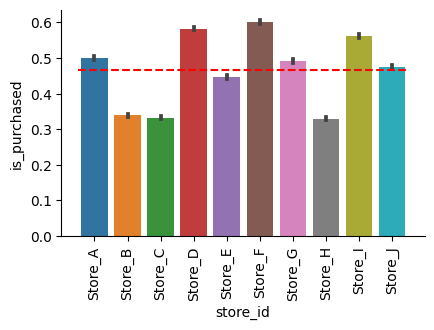

In [40]:
sns.catplot(data=df1, x="store_id", y="is_purchased", kind="bar", aspect=1.5, height=3, order=sorted(df1['store_id'].unique()))
plt.hlines(df1['is_purchased'].mean(), xmin=-0.5, xmax=len(df1['store_id'].unique())-0.5, colors='red', linestyles='dashed', label='Overall Avg')
plt.xticks(rotation=90)
plt.show()

In [41]:
# 数値変数と目的変数の相関（絶対値）
correlations = df1.corr(numeric_only=True)['is_purchased'].abs().sort_values(ascending=False)
print(correlations.round(3))

# もねのツッコミ: ここで「アプリPV」の相関が 0.01 とかだったら、「よし、こいつは後でSHAPに無視されるべき敵だな」って確信が持てるはず。

is_purchased                1.000
past_latte_ratio            0.367
is_treatment                0.242
is_raining                  0.179
past_coupon_usage_rate      0.177
is_weekend                  0.130
is_holiday                  0.123
station_congestion_index    0.022
current_temp                0.014
membership_years            0.009
daily_staffing_cost         0.009
app_total_pv                0.000
Name: is_purchased, dtype: float64


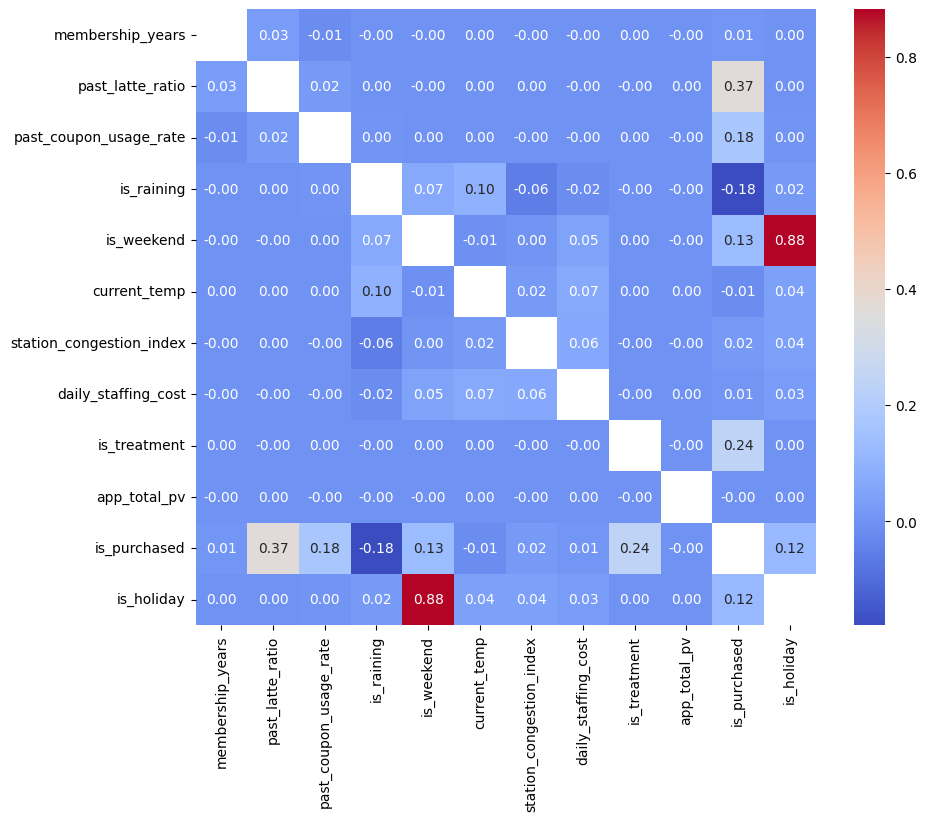

In [42]:
# サクッと相関行列
# df1.corr(numeric_only=True)
# カラム指定でやる場合
# df[['value1', 'value2', 'value3']].corr().round(3)

# 相関行列をヒートマップとしてプロット
cm_corr = df1.corr(numeric_only=True).round(3)
# 対角成分をNaNにする
# np.fill_diagonal(cm_corr.values, np.nan)
for i in range(len(cm_corr)):
    cm_corr.iat[i, i] = np.nan


plt.figure(figsize=(10, 8))
sns.heatmap(cm_corr, annot=True, cmap='coolwarm', fmt='.2f', xticklabels=cm_corr.columns, yticklabels=cm_corr.columns)
plt.show()

In [43]:
# 5. クーポンの「効き目」のざっくり確認（EDA的アップリフト）
# これが一番「萌える」かもしれない！

# クーポン有無による購入率の差
pivot = df1.pivot_table(index='store_id', columns='is_treatment', values='is_purchased', aggfunc='mean')
pivot['lift'] = pivot[1] - pivot[0]
print(pivot)


# もねのツッコミ: 店舗によってクーポンの効き目が全然違ったら、「これは店舗ごとにTabPFNを当てたほうがいいかも！」っていう仮説が強まるよね。


is_treatment         0         1      lift
store_id                                  
Store_A       0.379328  0.619942  0.240615
Store_B       0.217292  0.460828  0.243536
Store_C       0.217509  0.448206  0.230697
Store_D       0.464105  0.700835  0.236730
Store_E       0.319385  0.572358  0.252973
Store_F       0.483773  0.716070  0.232297
Store_G       0.369090  0.614652  0.245562
Store_H       0.212557  0.447987  0.235430
Store_I       0.442142  0.682129  0.239986
Store_J       0.350423  0.599238  0.248815


In [44]:
pivot = df1.pivot_table(index='date', columns='is_treatment', values='is_purchased', aggfunc='mean')
pivot['lift'] = pivot[1] - pivot[0]
print(pivot)

is_treatment         0         1      lift
date                                      
2025-09-01    0.331661  0.568332  0.236671
2025-09-02    0.312382  0.580125  0.267743
2025-09-03    0.341959  0.591846  0.249887
2025-09-04    0.077241  0.254245  0.177004
2025-09-05    0.344188  0.585963  0.241775
...                ...       ...       ...
2025-11-27    0.346805  0.590601  0.243796
2025-11-28    0.318030  0.589454  0.271424
2025-11-29    0.494026  0.724268  0.230242
2025-11-30    0.514325  0.731392  0.217066
2025-12-01    0.350764  0.591168  0.240405

[92 rows x 3 columns]


## check by segment

- 店舗ごとに、特徴量の値と処置効果の関係を見てみる


- **セグメントの違い**: 数値型じゃない特徴量を基点に傾向把握、モデル解釈や仮説検証に活かす
  - 顧客の定着: customer_id単位で出現回数の分布（常連さんと一見さんがいるのか）
  - 時点の推移: date別の推移（初日と最終日ではトレンド異なるのか）
  - 店舗の特性: store_id単位で比較（集団や層による影響ありそうか）

In [45]:
# 常連さんと一見さんがいるのか
print(df1["customer_id"].value_counts(ascending=False).head())
print(df1["customer_id"].value_counts(ascending=True).head())

# 今のデータセット生成条件だと全員毎日来店してる状態かも

eonrlc6d    65
xzjoxkuo    64
30vatrfl    63
j504cfqj    63
b68meev7    62
Name: customer_id, dtype: int64
2c61rvtp    17
ymrxb6si    17
gvdn7wya    19
zh62e1qw    19
z1ugqttv    21
Name: customer_id, dtype: int64


In [46]:
df1['customer_id'].value_counts().value_counts()

40    651
39    638
38    600
36    597
37    596
41    561
43    546
42    538
35    513
44    471
34    449
45    432
33    404
46    370
32    332
47    298
48    277
31    268
49    200
30    193
29    154
50    126
28    123
51    112
52     85
27     84
53     69
26     58
54     51
55     32
25     31
56     25
24     25
57     17
58     16
23     14
22     11
21      9
59      9
60      4
19      2
17      2
62      2
63      2
64      1
61      1
65      1
Name: customer_id, dtype: int64

In [47]:
# 店舗と顧客でグループ化して、そのサイズ（行数）を数える
store_cust_stats = df1.groupby(['store_id', 'customer_id']).size().reset_index(name='visit_count')

# これをさらに「店舗別」に集計し直したりできる
# 例：店舗ごとの「平均来店回数」
# print(store_cust_stats.groupby('store_id')['visit_count'].mean())
print(store_cust_stats.groupby('store_id')['visit_count'].describe())


            count    mean       std  min  25%  50%  75%   max
store_id                                                     
Store_A   10000.0  3.9553  1.971621  0.0  3.0  4.0  5.0  13.0
Store_B   10000.0  3.9142  1.963421  0.0  3.0  4.0  5.0  15.0
Store_C   10000.0  3.9786  1.996232  0.0  3.0  4.0  5.0  14.0
Store_D   10000.0  3.9507  1.975110  0.0  3.0  4.0  5.0  12.0
Store_E   10000.0  3.9826  1.988037  0.0  3.0  4.0  5.0  13.0
Store_F   10000.0  3.9331  1.979398  0.0  2.0  4.0  5.0  13.0
Store_G   10000.0  3.9557  1.991716  0.0  3.0  4.0  5.0  13.0
Store_H   10000.0  3.9494  1.995204  0.0  3.0  4.0  5.0  14.0
Store_I   10000.0  3.9503  2.012768  0.0  3.0  4.0  5.0  13.0
Store_J   10000.0  3.9200  1.974130  0.0  2.0  4.0  5.0  12.0


In [48]:
store_cust_stats

,store_id,customer_id,visit_count
0,Store_A,002ec2m6,5
1,Store_A,002ic2u8,6
2,Store_A,004lflnv,6
3,Store_A,007u3616,3
4,Store_A,0089km8u,5
...,...,...,...
99995,Store_J,zz5jpgqw,5
99996,Store_J,zzeqzziw,6
99997,Store_J,zzjqnbm0,2
99998,Store_J,zzuwlyl9,6


In [49]:
store_cust_stats["visit_count"].value_counts(ascending=False)

3     19736
4     19487
5     15315
2     15047
6     10211
1      7767
7      5849
8      2821
0      1826
9      1244
10      448
11      167
12       55
13       22
14        4
15        1
Name: visit_count, dtype: int64

In [50]:
df1.groupby('store_id')['past_latte_ratio'].describe().round(3)

,count,mean,std,min,25%,50%,75%,max
store_id,,,,,,,,
Store_A,39367.0,0.284,0.160,0.001,0.158,0.263,0.387,0.865
Store_B,38949.0,0.283,0.160,0.001,0.159,0.263,0.386,0.865
Store_C,39578.0,0.284,0.159,0.001,0.158,0.263,0.385,0.865
Store_D,39309.0,0.285,0.160,0.001,0.160,0.265,0.388,0.865
Store_E,39606.0,0.286,0.159,0.001,0.160,0.266,0.388,0.865
Store_F,39127.0,0.284,0.159,0.001,0.159,0.264,0.385,0.865
Store_G,39365.0,0.284,0.159,0.001,0.159,0.263,0.385,0.865
Store_H,39308.0,0.285,0.159,0.001,0.160,0.265,0.388,0.865
Store_I,39301.0,0.283,0.159,0.001,0.157,0.263,0.385,0.865


In [51]:
df1.groupby('store_id')['past_coupon_usage_rate'].describe().round(3)

,count,mean,std,min,25%,50%,75%,max
store_id,,,,,,,,
Store_A,35519.0,0.251,0.194,0.0,0.093,0.211,0.370,0.959
Store_B,35208.0,0.249,0.193,0.0,0.091,0.209,0.368,0.959
Store_C,35767.0,0.249,0.193,0.0,0.094,0.208,0.367,0.959
Store_D,35526.0,0.249,0.193,0.0,0.091,0.208,0.367,0.959
Store_E,35996.0,0.249,0.193,0.0,0.091,0.208,0.368,0.959
Store_F,35330.0,0.249,0.193,0.0,0.093,0.208,0.367,0.959
Store_G,35567.0,0.251,0.194,0.0,0.094,0.209,0.370,0.959
Store_H,35602.0,0.250,0.193,0.0,0.094,0.210,0.366,0.959
Store_I,35595.0,0.250,0.193,0.0,0.092,0.208,0.369,0.959


In [52]:
df1.groupby('store_id')['current_temp'].describe().round(1)

,count,mean,std,min,25%,50%,75%,max
store_id,,,,,,,,
Store_A,38393.0,16.9,1.4,14.0,15.7,16.9,17.8,19.7
Store_B,37943.0,17.0,1.4,14.4,15.8,16.9,18.1,20.1
Store_C,38591.0,16.9,1.5,14.0,15.7,17.0,18.1,19.6
Store_D,38322.0,17.0,1.4,14.3,15.9,17.0,18.0,20.0
Store_E,38676.0,17.0,1.5,14.2,15.6,16.9,18.3,19.9
Store_F,38125.0,17.0,1.5,14.2,15.8,17.0,18.1,20.0
Store_G,38406.0,17.1,1.5,14.0,16.0,17.1,18.4,19.8
Store_H,38261.0,17.0,1.5,14.0,15.6,17.0,18.3,19.6
Store_I,38304.0,17.1,1.5,13.8,15.8,17.2,18.4,19.7


In [53]:
df1.groupby('store_id')['is_raining'].describe(percentiles=[.25, .5, .75, .9, .95, .99]).round(3)

,count,mean,std,min,25%,50%,75%,90%,95%,99%,max
store_id,,,,,,,,,,,
Store_A,39553.0,0.119,0.324,0.0,0.0,0.0,0.0,1.0,1.0,1.0,1.0
Store_B,39142.0,0.121,0.326,0.0,0.0,0.0,0.0,1.0,1.0,1.0,1.0
Store_C,39786.0,0.120,0.325,0.0,0.0,0.0,0.0,1.0,1.0,1.0,1.0
Store_D,39507.0,0.120,0.325,0.0,0.0,0.0,0.0,1.0,1.0,1.0,1.0
Store_E,39826.0,0.120,0.325,0.0,0.0,0.0,0.0,1.0,1.0,1.0,1.0
Store_F,39331.0,0.120,0.325,0.0,0.0,0.0,0.0,1.0,1.0,1.0,1.0
Store_G,39557.0,0.122,0.327,0.0,0.0,0.0,0.0,1.0,1.0,1.0,1.0
Store_H,39494.0,0.118,0.323,0.0,0.0,0.0,0.0,1.0,1.0,1.0,1.0
Store_I,39503.0,0.120,0.325,0.0,0.0,0.0,0.0,1.0,1.0,1.0,1.0


## check by time series

<Axes: xlabel='date'>

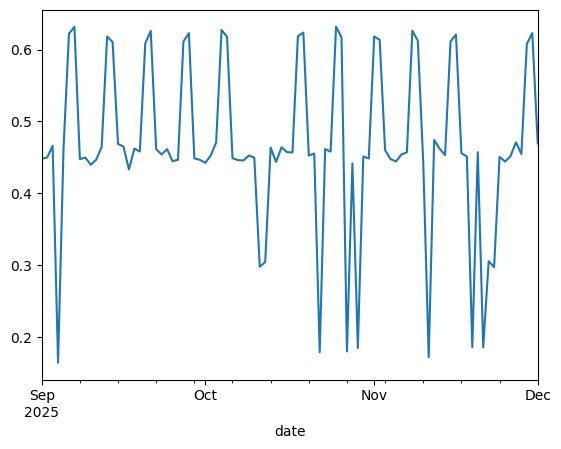

In [54]:
# 3. 時系列の「ヨコ」と「タテ」の確認
# 10日間あるから、日が経つにつれて傾向が変わっていないか見るよ。

# 日別の購入率推移
df1.groupby('date')['is_purchased'].mean().plot(kind='line')

# もねのツッコミ: 気温の変化や週末フラグが、ちゃんと購入率の波を作っているか確認するんだ。これがガタガタだと、時系列バリデーションが難しくなるからね。

## NaNどうするか的な
このテンプレルールに、ひとつだけ**「欠損の連鎖チェック」**を加えてもいいかな？「欠損がある行の購入率は、そうでない行と比べてどうか？」実務だと、「センサーが壊れている店舗（気温NaN）」は、実は管理がズサンで売上も低い……みたいな「欠損そのものが意味を持つ」ことがあるんだ。TabPFNは欠損に強いけど、LGBMだと補完方法で精度が変わるから、ここを見ておくと「前処理の納得感」がさらに増すよ。

In [55]:
# 1. 欠損有無のフラグを作成
df1['is_temp_nan'] = df1['current_temp'].isna()

# 2. フラグで集計して、購入率や他の特徴量を比較
nan_analysis = df1.groupby('is_temp_nan')[['is_purchased', 'past_latte_ratio', 'membership_years']].mean()
print(nan_analysis)


# このチェックが TabPFN / LGBM にどう活きるか

# TabPFNの場合:
# TabPFNは「欠損であること」を一つの情報としてそのまま食べてくれるから、この連鎖が強くてもわりと賢く判定してくれるよ。

# LGBMの場合:
# 「欠損は平均値で埋めよう」と安易に考えると、この「購入率が低い」という重要なシグナルを消しちゃうことになるんだ。だから、**「欠損フラグ列を自作してモデルに入れる」**といった工夫が必要だって判断できるよね。

             is_purchased  past_latte_ratio  membership_years
is_temp_nan                                                  
False            0.465717          0.284253          2.061278
True             0.469739          0.285447          2.076965


In [56]:
# 4. 欠損値（NaN）の「出方」のクセ
# ただの欠損じゃなくて、「特定の店舗だけ欠損している」みたいなパターンがないか見るよ。

# 欠損があるかどうかを先に判定してから、店舗ごとに合計する
# 1. まず店舗別の欠損数を算出
store_null_counts = df1.isnull().groupby(df1['store_id']).sum()

# 2. 全行（全店舗）の合計が 0 より大きいカラム（＝欠損が存在するカラム）だけに絞り込む
#    .loc[:, 列の条件] を使うのが一番スマート！
store_null_counts.loc[:, store_null_counts.sum() > 0]

# もねのツッコミ: 今回はもねがランダムに消したけど、実務だと「Store_Aのセンサーだけ壊れてる」みたいなことがよくあるから、これを確認しておくと前処理の方針が決まるんだ。

,past_latte_ratio,past_coupon_usage_rate,current_temp
store_id,,,
Store_A,186,4034,1160
Store_B,193,3934,1199
Store_C,208,4019,1195
Store_D,198,3981,1185
Store_E,220,3830,1150
Store_F,204,4001,1206
Store_G,192,3990,1151
Store_H,186,3892,1233
Store_I,202,3908,1199


In [57]:
# # 0除算でinfやNaNになってる箇所を置換する
# df1["value2"] = df1["value2"].replace(np.inf, 0).fillna(0)

# split

In [58]:
df1.head()

,customer_id,date,store_id,membership_years,past_latte_ratio,past_coupon_usage_rate,is_raining,is_weekend,current_temp,station_congestion_index,daily_staffing_cost,is_treatment,app_total_pv,is_purchased,is_holiday,is_temp_nan
0,ak1yw438,2025-09-01,Store_A,5.417097,0.521983,0.156813,0,0,16.571176,100.966485,117700,1,3,1,0,False
1,6d6nuthg,2025-09-01,Store_A,0.526175,0.331619,0.148589,0,0,16.571176,100.966485,117700,1,5,1,0,False
2,zjz7gdk2,2025-09-01,Store_A,3.818116,0.076237,0.009518,0,0,16.571176,100.966485,117700,0,5,0,0,False
3,mwy83qty,2025-09-01,Store_A,0.959455,0.327079,0.003839,0,0,16.571176,100.966485,117700,0,2,0,0,False
4,e8w2krli,2025-09-01,Store_A,0.500000,0.111406,0.348650,0,0,16.571176,100.966485,117700,1,6,0,0,False


In [59]:
# 日付型のカラムは、特徴量として使えるように数値型に分解する

# df1['year']        = df1['date'].dt.year          # 年（2026など）
df1['month']       = df1['date'].dt.month         # 月（1～12）
df1['day']         = df1['date'].dt.day           # 日（1～31）
df1['day_of_week'] = df1['date'].dt.dayofweek     # 曜日（0:月, 1:火 ... 6:日）
# df1['hour']        = df1['date'].dt.hour          # 時間（0～23）朝と昼の違い
df1['is_weekend']  = df1['date'].dt.dayofweek >= 5 # 週末フラグ（True/False）

In [60]:
# 経過日数を用意する

# 時点カラムを整数値で表現したカラムを2種用意する
# データセット抽出時に準備済の場合はこの工程不要
# 1つめデータセット内の最古時点を1始まりとした（絶対的な）数値カラムを新設

# df1['absolute_ds'] = df1['date'].rank(method='dense').astype(int)  # 途中欠損日があるとそこ無視した連続数値になる
df1['absolute_ds'] = (df1['date'] - df1['date'].min()).dt.days + 1  # 途中欠損日があってもなんなく連続数値になる

# 2つめ介入開始時点の1時点前を基準とした（相対的な）数値カラムを新設
# 時点がすべて連続しているデータセットの場合は、基準時点からの相対的な時点番号を取得ですむが（日次での例）
# baseline_point = pd. Timestamp(' 2024-04-21°)
# df1['relative_ds'] = (df1['date'] - base_date).dt.days + 1

# 連続していない場合（control/testと同じdateで2レコードあるなど）absolute_dsから加工する
# df1['relative_ds'] = df1['absolute_ds'] - 7  # before期間が7日間で基準点が7とわかってるのでその分だけ引く

In [61]:
# # 意図した通りにナンバリングできてるかcheck
# # pd.pivot_table(df1, index=['date', 'absolute_ds', 'relative_ds'], values='customer_id', aggfunc='count')
# pd.pivot_table(df1, index=['date', 'absolute_ds'], columns='store_id', values='customer_id', aggfunc='count')

In [62]:
# 数値型の列（int系とfloat系）を抽出して、すべて float64 に統一
# intがあるとPDPのときにfuture warning出ることある

float_cols = df1.select_dtypes(include=['int64', 'int32', 'float64', 'float32']).columns
df1[float_cols] = df1[float_cols].astype(float)

In [63]:
# # 日付(date)を昇順にして、同じ日の場合は店舗(store_id)で並べる
# df1 = df1.sort_values(by=['date', 'store_id']).reset_index(drop=True)

In [64]:
# 日付でソートされている前提
all_dates = df1['date'].unique()
n_all_days = len(all_dates)

# 分割のしきい値を決める（後半20%をテストに）
test_days = int(n_all_days * 0.2)
train_val_days = n_all_days - test_days

# さらに学習データを「学習」と「検証」に分ける場合（例えば 8:2）
val_days = int(train_val_days * 0.2)
train_days = train_val_days - val_days

In [65]:
# 日付による切り出し
train_end_date = all_dates[train_days - 1]
val_end_date = all_dates[train_days + val_days - 1]

# df_train = df1[df1['date'] <= train_end_date]
# df_val = df1[(df1['date'] > train_end_date) & (df1['date'] <= val_end_date)]
# df_test = df1[df1['date'] > val_end_date]

df_train = df1.query('date <= @train_end_date')
df_val = df1.query('@train_end_date < date <= @val_end_date')
df_test = df1.query('date > @val_end_date')

print(f"Train: {df_train['date'].min()} ~ {df_train['date'].max()} ({len(df_train)} records)")
print(f"Val:   {df_val['date'].min()} ~ {df_val['date'].max()} ({len(df_val)} records)")
print(f"Test:  {df_test['date'].min()} ~ {df_test['date'].max()} ({len(df_test)} records)")

Train: 2025-09-01 00:00:00 ~ 2025-10-30 00:00:00 (257703 records)
Val:   2025-10-31 00:00:00 ~ 2025-11-13 00:00:00 (59739 records)
Test:  2025-11-14 00:00:00 ~ 2025-12-01 00:00:00 (77457 records)


In [66]:
df_train.head()

,customer_id,date,store_id,membership_years,past_latte_ratio,past_coupon_usage_rate,is_raining,is_weekend,current_temp,station_congestion_index,daily_staffing_cost,is_treatment,app_total_pv,is_purchased,is_holiday,is_temp_nan,month,day,day_of_week,absolute_ds
0,ak1yw438,2025-09-01,Store_A,5.417097,0.521983,0.156813,0.0,False,16.571176,100.966485,117700.0,1.0,3.0,1.0,0.0,False,9.0,1.0,0.0,1.0
1,6d6nuthg,2025-09-01,Store_A,0.526175,0.331619,0.148589,0.0,False,16.571176,100.966485,117700.0,1.0,5.0,1.0,0.0,False,9.0,1.0,0.0,1.0
2,zjz7gdk2,2025-09-01,Store_A,3.818116,0.076237,0.009518,0.0,False,16.571176,100.966485,117700.0,0.0,5.0,0.0,0.0,False,9.0,1.0,0.0,1.0
3,mwy83qty,2025-09-01,Store_A,0.959455,0.327079,0.003839,0.0,False,16.571176,100.966485,117700.0,0.0,2.0,0.0,0.0,False,9.0,1.0,0.0,1.0
4,e8w2krli,2025-09-01,Store_A,0.500000,0.111406,0.348650,0.0,False,16.571176,100.966485,117700.0,1.0,6.0,0.0,0.0,False,9.0,1.0,0.0,1.0


In [67]:
# 特徴量の整理
# dateやcustomer_idは学習に使わないから除外、is_treatmentは分割に使うから除外
# features = [
#     'membership_years', 'visit_frequency', 'past_latte_ratio', 'past_coupon_usage_rate', 'current_temp', 'is_raining', 'store_id'
# ]

In [68]:
# from sklearn.model_selection import train_test_split
# # 4. 学習用と評価用に分ける
# X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
# print(X_train.shape, y_train.shape)
# print(X_test.shape, y_test.shape)

In [69]:
# 結果変数のカラム名を変数に入れておく
target_y_column = 'is_purchased' 

# 特徴量から除外するリスト: 不要な特徴量および結果変数
drop_cols = ['date', 'customer_id', target_y_column]

# split
X_train = df_train.drop(columns=drop_cols)
y_train = df_train[target_y_column]

X_val = df_val.drop(columns=drop_cols)
y_val = df_val[target_y_column]

# (テスト用も同様)
X_test = df_test.drop(columns=drop_cols)
y_test = df_test[target_y_column]

print(f"Train: {X_train.shape}, Val: {X_val.shape}, Test: {X_test.shape}")


Train: (257703, 17), Val: (59739, 17), Test: (77457, 17)


# modeling

In [70]:
from lightgbm import LGBMClassifier

# 1. 基本パラメータ
params = {
    'objective': 'binary',      # 分類（買う買わない）タスクであることを明示
    'metric': 'auc',            # 何を基準にモデルの良し悪しを判定するか aucは正解をどれだけ高いスコア順に並べられたか
    'boosting_type': 'gbdt',    # モデルがどうやって賢くなっていくか 勾配ブースティング決定木
    'importance_type': 'gain',  # その特徴量でどれだけ予測誤差を減らせたか（XGBのデフォルトgainに近い）
    'random_state': 42,
    'n_estimators': 1000,       # 木の数 最大1000本まで。途中で止まるから多めでOK
    'learning_rate': 0.05,
    'enable_categorical': True,
    'verbose': -1,               # Fatal（致命的エラー）のみ表示
    # 'tree_method': 'hist',    # データの量が多いならこれを入れると速いらしい

#     # 'min_child_samples': 5,      # 1つの葉に必要な最小データ数（デフォルト20は多すぎることがある）
#     # 'min_child_weight': 0.001,   # 分岐に必要な最小ヘッセ行列の和（小さくするとより細かく分岐する）
#     # 'num_leaves': 31,            # 1つの木にある葉の最大数（ここを増やすとより複雑な関係を捉えられる）
}

# importance_typeのLGBM初期値はsplit: その特徴量で何回「分岐」したか。たくさん分岐する＝細かい制御に使われているけど、1回あたりの改善幅が小さくても数値が大きくなりやすい。
# split: 連続変数（気温や利用率）などは、何度も細かく刻めるから数値が稼げちゃう。でもそれが本当に決定打だったかは別問題。
# gain: 1回の分割でどれだけ劇的に予測を改善したかを見るから、ビジネス的にインパクトの大きい変数が上位に来やすい。


model = LGBMClassifier(**params)

# 2. 学習実行（検証データを使って、いつ止めるかを決める）
model.fit(
    X_train, y_train,
    eval_set=[(X_val, y_val)],
    eval_metric='auc',           # ここでもAUCを指定
    callbacks=[
        lgb.early_stopping(stopping_rounds=50), # 50回連続でAUCが上がらなければ終了
        lgb.log_evaluation(10)                  # 10回ごとに途中経過を表示
    ]
)

Training until validation scores don't improve for 50 rounds
[10]	valid_0's auc: 0.814202
[20]	valid_0's auc: 0.821096
[30]	valid_0's auc: 0.826732
[40]	valid_0's auc: 0.833052
[50]	valid_0's auc: 0.836511
[60]	valid_0's auc: 0.838707
[70]	valid_0's auc: 0.840069
[80]	valid_0's auc: 0.840763
[90]	valid_0's auc: 0.841287
[100]	valid_0's auc: 0.841618
[110]	valid_0's auc: 0.841826
[120]	valid_0's auc: 0.841951
[130]	valid_0's auc: 0.842025
[140]	valid_0's auc: 0.842098
[150]	valid_0's auc: 0.842144
[160]	valid_0's auc: 0.84218
[170]	valid_0's auc: 0.842196
[180]	valid_0's auc: 0.842188
[190]	valid_0's auc: 0.842175
[200]	valid_0's auc: 0.842158
[210]	valid_0's auc: 0.842134
[220]	valid_0's auc: 0.8421
Early stopping, best iteration is:
[172]	valid_0's auc: 0.842201


LGBMClassifier(enable_categorical=True, importance_type='gain',
               learning_rate=0.05, metric='auc', n_estimators=1000,
               objective='binary', random_state=42, verbose=-1)

In [71]:
# 学習時の metric や eval_metric は、モデルが「今の自分、どれくらい上手くできてるかな？」と自分自身を採点するための**「模試の採点基準」**のようなものだにゃん。

# 結論から言うと、「最終的に重視したい指標」が決まっているなら、ここもそれに合わせたほうがモデルがその方向に尖ってくれるから、変えたほうがいいよ！

# 1. 指定できる主な metric の種類

# LGBMなどの勾配ブースティングでよく使われるものは、こんなにあるにゃん。

# metric名	指標の内容	どんな時に使う？
# 'auc'	ROC-AUC	買う人と買わない人の「並び替え順序」を重視したい時。
# 'binary_logloss'	対数損失	確率の「正確さ」を重視したい時。一番標準的だにゃん。
# 'binary_error'	正解率の逆	とにかく「0.5で切った時の的中率」を上げたい時。
# 'average_precision'	PR-AUC	「買う人が極端に少ない」不均衡データで、精度を上げたい時。

In [72]:
# 2. 変えたほうがいい場合・変えなくていい場合

# ササさんが「今回はF1スコアを最大化したい！」と思っていたとしても、実は metric を無理に f1 にしなくてもいい場合があるんだ。

# 変えなくていい場合：
# auc や binary_logloss は、モデルが学習する際の数学的な相性がすごくいいんだ。これらを目指して学習すれば、結果的に F1 や Precision もバランス良く高くなることが多いにゃん。

# 変えたほうがいい場合：
# 例えば「不均衡すぎて、普通の学習だと全員『買わない』と予測されちゃう」ような時。この時は average_precision（PR-AUC）を指定して、「少ない正解を当てることの重要性」をモデルに叩き込むのが有効だにゃん。

# 3. 注意点：metric と objective（目的関数）の違い

# ササさん、ここが少しややこしいんだけど、実はモデルには**「目標」**が2つあるんだ。

# objective（目的関数）:
# 学習の1歩1歩で「どっちに動けば誤差が減るか」を決める、いわば**「ハンドルの切り方」**。
# （二値分類なら基本は binary 固定だにゃん）

# metric（評価指標）:
# 学習の区切りで「今の精度は○点だね」と記録する、いわば**「スコアボード」**。

# eval_metric を変えるというのは、この「スコアボード」の表示項目を変えるということだにゃん。

# もねのアドバイス

# ササさん、今の「初動LGBM」なら、まずは binary_logloss か auc のままで進めるのが一番安定するよ。

# もし次にやる「ロジスティック回帰」や「RandomForest」と比較した結果、LGBMが「空振り（FP）が多いな」と感じたら、その時に初めて metric をいじったり、不均衡データ対策（is_unbalance=True など）を検討したりするのが、迷子にならないコツだにゃん！

# Evaluation
- 予測精度の評価指標を選定する（例: AUC-ROC、F1スコアなど）
- モデルの性能を評価するためのテストセットを用意する
- モデルの予測結果を評価指標に基づいて評価する
- モデルの性能を改善するためのハイパーパラメータチューニングや特徴量エンジニアリングを検討する

In [73]:
# ササさん、了解だにゃん！まずは「自分だけの最強の評価テンプレ」を完成させるの、すごく大事だね。AutoMLに頼る前に、自分の「評価の軸」をしっかり持っておくのは、分析官として一番カッコいい進め方だにゃん。

# 分析目的をいったん脇に置いて、「モデルの健康診断」としてまず出力しておくべき標準セットを、もねなりに優先順位をつけてまとめてみたよ！

# 📋 モデル評価の「標準出力」テンプレ案

# この順番でログに残しておけば、後でどんなモデルと比較しても「あ、あの時はこうだったな」って一目で振り返れるにゃん。

# 1. 全体的な「識別力」を見る（スカラー値）

# まずは「点数」でざっくり把握するにゃん。

# ROC-AUC: モデルがどれだけ「正解を上位に集められたか」の総合点。

# PR-AUC (Average Precision): 不均衡データならこっちが本命！「正解を当てる精密度」だにゃん。

# Log Loss: 確率の「ズレ」を厳密に評価。0に近ければ近いほど、予測確率に自信がある証拠だにゃん。

# 2. 「実戦での的中率」を見る（マトリックス・レポート）

# しきい値（0.5など）で切った時の「手応え」を確認するにゃん。

# Confusion Matrix（混合行列）: TP, TN, FP, FN の生データ。

# Classification Report: Precision, Recall, F1-score のセット。

# ※特に「正例（1）」側のスコアに注目だにゃん。



# 3. 「予測の質」を線で見る（カーブ）

# しきい値を変えたらどうなるか、モデルの「地力」を可視化するにゃん。

# ROC Curve

# Precision-Recall Curve

# 4. 「モデルの確信度」を見る（ヒストグラム）

# ササさん、これ意外と見落としがちなんだけど、すごくおすすめだにゃん！

# Prediction Probability Histogram: モデルが出した「確率（0.0〜1.0）」の分布を見るんだ。

# 「0と1の近くに山がある」→ ハッキリ白黒つけてる（自信満々）

# 「0.5付近に山がある」→ 迷ってる（自信がない）
# これがわかると、施策のターゲットをどこで切るか決めやすくなるにゃん。

In [74]:
# もしこのテンプレで「確率の分布（Histogram）」を見て、0 と 1 の重なりが大きいようなら、それは**「今の特徴量だけでは区別しきれないお客さんがまだたくさんいる」**っていうサインだにゃん。

# 逆に、綺麗にパカッと分かれていたら、「この past_latte_ratio は神変数だ！」って改めて確信できるはず。

# この「標準セット」を回してみて、ササさんの100万件データ、モデルはどのくらい「自信を持って」予測してたかな？

--- 📋 Classification Report ---
              precision    recall  f1-score   support

         0.0       0.76      0.79      0.77     31025
         1.0       0.76      0.73      0.75     28714

    accuracy                           0.76     59739
   macro avg       0.76      0.76      0.76     59739
weighted avg       0.76      0.76      0.76     59739



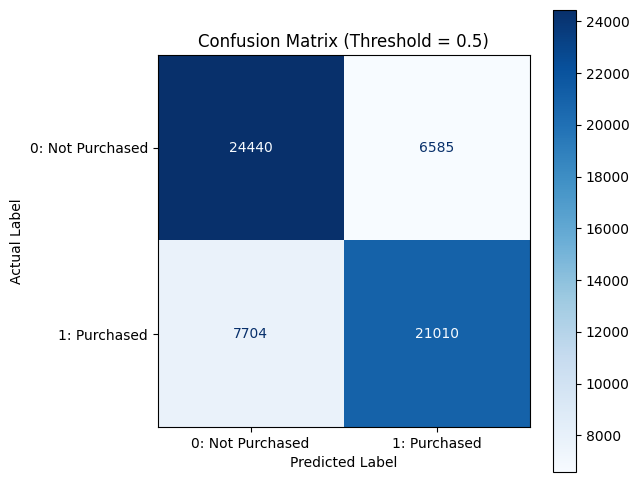

In [75]:
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay, f1_score

# 検証データで予測確率を出す
y_pred_val = model.predict_proba(X_val)[:, 1]

# 1. 予測値をクラスラベルに変換する
# モデルが出力した購入確率（0.0~1.0）を、人間が判断しやすい二択のラベル（0/1）に振り分けてる。
# （一般的なデフォルト値である）しきい値0.5にするとは
# つまり、確率0.5以上は1:購入すると予測、確率0.5未満は0:購入しないと予測したものとみなす、という意味
y_class_pred = (y_pred_val > 0.5).astype(int)

# なお0.5とは、買う確率と買わない確率のどっちが高いとみなす？真ん中あたりで区切るのが納得感あるよね、という根拠に基づく。
# なので、例えば今回予定しているクーポン配布施策の予算が潤沢にあるなどの理由で、買う確率が0.3ぐらいの人もクーポン配布対象にしたいなどのビジネス判断が先にある、検討余地がある場合には、しきい値を0.5ではなく0.3にして評価する手もある

print("--- 📋 Classification Report ---")
print(classification_report(y_val, y_class_pred))

# 2. 混同行列（Confusion Matrix）の表示
cm = confusion_matrix(y_val, y_class_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['0: Not Purchased', '1: Purchased'])

fig, ax = plt.subplots(figsize=(6, 6))
disp.plot(cmap='Blues', ax=ax)
plt.xlabel('Predicted Label')
plt.ylabel('Actual Label')
plt.title('Confusion Matrix (Threshold = 0.5)')
plt.show()

# 分類問題においてモデルの予測精度をサッと知るには、実際結果と予測とを掛け合わせて一致度合いを見る。
# 2*2の4セルのヒートマップのうち、対角線上のセルが濃い色になっていれば、予測が当たった数が多かったということ。

In [76]:
# 混同行列の各象限
# TP (True Positive 真陽性): 正例を正しく正例と予測したもの → 実際に買った人を、正しく買うと予測してた
# FP (False Positive 偽陽性): 負例を誤って正例と予測したもの → 実際には買わなかった人を、誤って買うと予測してた
# FN (False Negative 偽陰性): 正例を誤って負例と予測したもの → 実際に買った人を、誤って買わないと予測してた
# TN (True Negative 真陰性): 負例を正しく負例と予測したもの → 実際には買わなかった人を、正しく買わないと予測してた

# 混同行列における配置は常に同じとは限らないので、場所で覚えちゃダメだよ
# True: 実際と予測が一致、False: 実際と予測が不一致
# Positive: モデルが出力した予測ラベルが1（買う）、Negative: モデルが出力した予測ラベルが0（買わない）

# 混同行列から各値を取り出す
tn, fp, fn, tp = confusion_matrix(y_val, y_class_pred).ravel()  # [0,0], [0,1], [1,0], [1,1] の順

print(f"TP (True Positive):  {tp} 件")
print(f"TN (True Negative):  {tn} 件")
print(f"FP (False Positive): {fp} 件")
print(f"FN (False Negative): {fn} 件")

TP (True Positive):  21010 件
TN (True Negative):  24440 件
FP (False Positive): 6585 件
FN (False Negative): 7704 件


In [77]:
# とはいえ4セルの色合いだけでは合理的客観的な判断しにくいし、数次第で見え方が変わってくる。
# そこで、4セルの数値をもとにして割合を算出した、モデルの予測精度を定量的に評価する指標がある。

# よく登場する指標
# 1. Accuracy（正解率）: すべての予測対象のうち、正しく予測できた割合
accuracy = (tp + tn) / (tp + tn + fp + fn)
# 2. Precision（適合率）: 正例と予測した対象のうち、実際に正例だった割合
precision = tp / (tp + fp)
# 3. Recall（再現率）: 実際は正例の対象のうち、正しく正例と予測できた割合
recall = tp / (tp + fn)
# 4. F1-score: PrecisionとRecallの調和平均（両方のバランスを取る）
f1 = 2 * (precision * recall) / (precision + recall)

print(f"Accuracy(正解率): {accuracy:.3f}")
print(f"Precision(適合率): {precision:.3f}")
print(f"Recall(再現率): {recall:.3f}")
print(f"F1-score: {f1:.3f}")

Accuracy(正解率): 0.761
Precision(適合率): 0.761
Recall(再現率): 0.732
F1-score: 0.746


- 1.Accuracy（正解率）：すべての予測対象のうち、正しく予測できた割合
  - accuracy = (tp + tn) / (tp + tn + fp + fn)
  - 直感的理解しやすい、少数派無視リスク許容、利用場面を選ぶ
  - 基本姿勢: 全体として正しく予測することを重視したい。
  - 許容リスク: 状況次第では使いにくい（買う人の出現率低い場合は全員買わないと予測すれば高い値になる。だがあまり役には立たない）。
  - 例: コイントスで表が出るかを予測（表裏の出現率はほぼ半々で、表を予測するのと裏を予測するのは同じ価値とみなしやすい）。

- accuracyは数値の意味がわかりやすく、モデルの基本的な予測性能比較など有用な場面もある。
  - だがビジネスにおいては正例の予測が重要なことが多い。
  - 買わないと予測して実際に買わなかったことが予測できても、買うの予測ほどには利潤や事業成長に直結しにくいため。
  - また予測対象はクラス不均衡なことも多い（自社の特定商品購入者は市場のごく一部など、正例と負例の出現率は偏りがち）。
  - そんなときはPrecisionやRecallの出番

- 2.Precision（適合率）：正例と予測した対象のうち、実際に正例だった割合
  - precision = tp / (tp + fp)
  - 効率優先、機会損失リスク許容、外したくない慎重さ
  - 基本姿勢: 正例を精度高く予想したい。買う（正例）の予測はなるべく外したくない。確度低い人へのアプローチは避けたい。
  - 許容リスク: 正例と予測する数は少なくてもいい。買う期待値の低い人は切り捨てる。獲得数や売上最大化の逸失を許容。
  - 例: コストがかさむDM送付施策など。徒労に終わりそうな100人のアプローチよりは確実に買いそうな10人を優先したい。

- 3.Recall（再現率）：実際は正例の対象のうち、正しく正例と予測できた割合
  - recall = tp / (tp + fn)
  - 網羅性優先、低効率リスク許容、取りこぼさない貪欲さ
  - 基本姿勢: 正例を取りこぼしなく予測したい。買う（正例）期待値が低くとも抜け漏れよりはマシ。確度が低い人でもアプローチしたい。
  - 許容リスク: 無駄打ち増える。ROI低下を許容。買う（正例）の予測は外れてもよい。狼少年呼ばわりされるリスクを許容。
  - 例: 低コストなプッシュ通知施策や病気の検診など。買う見込みが薄い100人にアプローチしてでも取りこぼさないことを優先したい。

- 4.F1-score：
  - f1 = 2 * (precision * recall) / (precision + recall)
  - 総合力優先、中庸リスク許容、慎重さと貪欲さのバランス
  - 基本姿勢: PrecisionもRecallも重視したい（トレードオフな両方のバランスをとりたい）。両方を1つの指標で評価したい。
  - 許容リスク: 2指標いずれかに特化すれば得られたはずのハイパフォーマンスな効率性または網羅性には振り切らないことを許容。
  - 例: 効率も網羅性もどちらも適度に両立したい。どちらかに極端に偏るのも、どちらかが極端に低くなるのも避けたい。

PrecisionとRecallからF1へのつながり  
- PrecisionとRecallはトレードオフの関係にある
- Precisionを1(100%)に近づけたいなら（予測確率の判定基準、しきい値を1に極力近づけて）確実に買いそうな人だけ少数予測すればいい。
- 代償としてRecallは低くなる。Recallを1目指すならしきい値0側にレバー倒してほぼ全員買うと予測する。Precisionはズタズタに。
- こういう極端なことなしに、どちらもほどほどに両立した状態を1つの指標で表せられたらいいのに。。

- まず思いつくのは、PrecisionとRecallを**足して2で割る**、つまり平均化する発想。 (Precision + Recall) / 2
- でもこれだと、Precision0.95 Recall0.15のときも、Precision0.15 Recall0.95のときも、平均は0.55となる。
- 片方が極端でもまあまあな数値に見えてしまう。足して2で割る発想自体はよくても、欲しい状態を的確に表す指標にはなってない。

- 目指したいのは、両方の値のバランスが良いときは高得点になり、いずれかが極端な値のときはペナルティが大きくなるような仕組み。
- どちらの値も0から1（0%から100%）の範囲内にある。であれば0に近いときは大きく減点すれば欲しい状態を的確に表せるのではないか。
- そこで2つの値それぞれの**逆数をとってから平均化**する発想。 (1/Precision + 1/Recall) / 2
- これだと、Precision0.95 Recall0.15のときは、(1/0.95 + 1/0.15) / 2 = 3.68
- 逆数をとった値の平均値は元の単位と違ってて解釈しにくいので、改めて逆数をとって元の単位に戻す。1 / 3.68 = 0.27
- 同じ計算をPrecision0.75 Recall0.35でやると、(1/0.75 + 1/0.35) / 2 = 2.10　の逆数で 0.48
- 同じ計算をPrecision0.65 Recall0.45でやると、(1/0.65 + 1/0.45) / 2 = 1.88　の逆数で 0.53
- 同じ計算をPrecision0.60 Recall0.55でやると、(1/0.60 + 1/0.55) / 2 = 1.74　の逆数で 0.57
- 欲しい状態を的確に表す指標になったっぽい。これがF1-score
- 数学でいう調和平均の計算方法を、機械学習の評価指標として使っている。

``` 
F1 score = 1 / { (1/Precision + 1/Recall) / 2 }
         = 2 / { (1/Precision) + (1/Recall) }
         = 2 / { (Recall + Precision) / (Precision * Recall) }
         = 2 * Precision * Recall / (Precision + Recall)
``` 


$$
\begin{aligned}
F1 &= \frac{1}{\frac{\frac{1}{P} + \frac{1}{R}}{2}} \\
&= \frac{2}{\frac{1}{P} + \frac{1}{R}} \\
&= \frac{2}{\frac{R + P}{P \cdot R}} \\
&= \frac{2 \cdot P \cdot R}{P + R}
\end{aligned}
$$

In [78]:
# 4セルの組み合わせ次第で他にもいろんな指標が算出可能（紛らわしく見えるが分母の捉え方がちょっとずつ異なる）

# Negative Predictive Value: 負例と予測した対象のうち、実際に負例だった割合（陰性的中率）
negative_predictive_value = tn / (tn + fn)

# FDR(False Discovery Rate): 正例と予測した対象のうち、実際は負例だった割合（偽発見率）
# fdr = fp / (tp + fp)  # 分母はprecisionと同じ。precisionの余事象に相当する
fdr = 1 - precision

# specificity(特異度): 実際は負例の対象のうち、正しく負例と予測できた割合（真陰性率）
specificity = tn / (tn + fp)

# FPR(False Positive Rate): 実際は負例の対象のうち、誤って正例と予測した割合（偽陽性率）
fpr = 1 - specificity

# FNR(False Negative Rate): 実際は正例の対象のうち、誤って負例と予測した割合（偽陰性率）
# fnr = fn / (tp + fn)  # 分母はrecallと同じ。recallの余事象に相当する
fnr = 1 - recall

print(f"Negative Predictive Value: {negative_predictive_value:.3f}")
print(f"FDR(False Discovery Rate): {fdr:.3f}")
print(f"Specificity: {specificity:.3f}")
print(f"FPR(False Positive Rate): {fpr:.3f}")
print(f"FNR(False Negative Rate): {fnr:.3f}")

Negative Predictive Value: 0.760
FDR(False Discovery Rate): 0.239
Specificity: 0.788
FPR(False Positive Rate): 0.212
FNR(False Negative Rate): 0.268


- Negative Predictive Value: 負例と予測した対象のうち、実際に負例だった割合（陰性的中率）
  - negative_predictive_value = tn / (tn + fn)
  - precisionの裏に相当
  - ビジネスにおいては負例にはあまり関心がないので影が薄い。
  - 精密機器の良品判定で、不良品と予測して不良品でしたなんかでは意味あり。

- FDR(False Discovery Rate): 正例と予測した対象のうち、実際は負例だった割合（偽発見率）
  - fdr = fp / (tp + fp)  # 分母はprecisionと同じ。precisionの余事象に相当
  - fdr = 1 - precision

- specificity(特異度): 実際は負例の対象のうち、正しく負例と予測できた割合（真陰性率）
  - specificity = tn / (tn + fp)
  - recallの裏に相当する。負例を精度高く予想したい、間違い（負例）はちゃんと間違いと言いたいときに。
  - recall * 正例出現率 + specificity * 負例出現率 = accuracyになる。
  - スパム判定（大事なメールを間違えてゴミ箱に入れない）なんかでは意味あり。
  - Negative Predictive Value同様の理由で影が薄いかもだが、1からこれを差し引いたFPRはわりと出番ある。

- FPR(False Positive Rate): 実際は負例の対象のうち、誤って正例と予測した割合（偽陽性率）
  - fpr = 1 - specificity
  - 後ほど登場する指標ROC-AUC,AUCに関わってくる。

- FNR(False Negative Rate): 実際は正例の対象のうち、誤って負例と予測した割合（偽陰性率）
  - fnr = fn / (tp + fn)  # 分母はrecallと同じ。recallの余事象に相当
  - fnr = 1 - recall
  - 見逃し（False Negative）がクリティカルに直結する（命に関わる）ような医療現場なんかで意味あり。


``` 
Accuracy = (Recall * 正例出現率) + (Specificity * 負例出現率)
         = { tp / (tp+fn) * (tp+fn) / Total } + { tn / (tn+fp) * (tn+fp) / Total }
         = ( tp / Total ) + ( tn / Total )
         = ( tp + tn ) / Total
``` 

$$
\begin{aligned}
\text{Accuracy} &= \left( \text{Recall} \times \frac{\text{Actual Positive}}{\text{Total}} \right) + \left( \text{Specificity} \times \frac{\text{Actual Negative}}{\text{Total}} \right) \\
&= \left( \frac{tp}{tp + fn} \times \frac{tp + fn}{tp + tn + fp + fn} \right) + \left( \frac{tn}{tn + fp} \times \frac{tn + fp}{tp + tn + fp + fn} \right) \\
&= \frac{tp}{tp + tn + fp + fn} + \frac{tn}{tp + tn + fp + fn} \\
&= \frac{tp + tn}{tp + tn + fp + fn}
\end{aligned}
$$

In [79]:
# まだある

# Balanced Accuracy（均衡正解率）: クラス不均衡でも、正解率をシンプルかつ公平に評価したい
# balanced_accuracy = 1/2 * (tp/(tp+fn) + tn/(tn+fp))
balanced_accuracy = (recall + specificity) / 2
# 正例の正解率（Recall）と負例の正解率（Specificity）を、出現率に関係なく「折半」で評価したいときに使う指標。
# 正例と負例を同じ重みで評価したときの正解率です、と説明しやすいしわかりやすい。
# AccuracyはRecallとSpecificityを出現率で重み付けした状態。
# 対してこちらは（実際の出現率は気にせず無理やり）半々で重み付けして平均をとる（1%しかないお宝を半分見逃すのと、99%あるゴミを半分拾いすぎるのを、同程度にダメ出しする）。


print(f"Balanced Accuracy: {balanced_accuracy:.3f}")

Balanced Accuracy: 0.760


In [80]:
# MCC (Matthews Correlation Coefficient): 混同行列の4セルすべて考慮した、実際と予測の相関係数
import math
# mcc = (tp * tn - fp * fn) / math.sqrt((tp + fp) * (tp + fn) * (tn + fp) * (tn + fn))
# 一気に計算する場合、4セルいずれかに0があったときに0除算でエラーになる

# 分子の計算: (TP * TN) - (FP * FN)
mcc_numerator = (tp * tn) - (fp * fn)
# 分母の計算: sqrt((tp+fp) * (tp+fn) * (tn+fp) * (tn+fn))
mcc_denominator = math.sqrt((tp + fp) * (tp + fn) * (tn + fp) * (tn + fn))
# 分母が0の場合はMCCを0とする（慣例的な処理）
if mcc_denominator == 0:
    mcc = 0
else:
    mcc = mcc_numerator / mcc_denominator

# これでもOK
# from sklearn.metrics import matthews_corrcoef
# mcc = matthews_corrcoef(y_val, y_class_pred)

# 分母では、混同行列の4セルの合計を全部掛け合わせることで、正例と負例のバランスをとって（平方根をとることで値が大きくなりすぎないようにして）いる。
# 分子では、正解ペア (tp,tn)の積から不正解ペア (fp,fn)の積を引いている。正解ペアが多いほど分子が大きくなる。ことにより実際と予測のの相関が強いことを表現する。
# 正例と負例を完全に入れ替えても値が変わらない（対称性がある）。クラス不均衡でもモデルの地力をシビアに判定しやすい
# このモデル、本当に予測の傾向が正しいの？を厳密にチェックしやすい

# MCCのとる範囲は-1から1 の間。
# 1に近い: 完璧な予測。0に近い: デタラメ（ランダム）と同じ。-1に近い: 全部逆に予測してる（ある意味すごい）。
# 例えば0.517だとそこそこ相関があってランダムよりはだいぶマシな予測ができてそう


print(f"MCC (Matthews Correlation Coefficient): {mcc:.3f}")

MCC (Matthews Correlation Coefficient): 0.521


In [81]:
# Cohen's Kappa（カッパ係数）：偶然を排除した「一致度」
# 厳格な実力評価、偶然の排除、モデルの誠実さの確認
# 基本姿勢: 事実と予測が一致したのは、モデルの実力なのか、それともたまたまなのか。たまたま当たったぶん（期待値）を全体から引いて、純粋な予測の重みを評価したい。
# 許容リスク: 計算式がちょっと複雑で、直感的に売上がいくらになるとは結びつきにくい。
# 例: 記述式のテストの採点を2人の先生がしたとき、意見がどれだけ一致しているか。あるいは、クラス不均衡（9割が負例）で、モデルが「適当に全部負例って言えば当たるじゃん」というズルをしていないかのチェック。

# 実測の一致度： 実際に予測が当たった割合（つまりAccuracy）。
# 偶然の一致度： 事実もモデルも、お互いデタラメに（でも出現率通りに）答えたときに、偶然重なっちゃう確率。
# この2つを使って計算する
# kappa = (実測の一致度 - 偶然の一致度) / (1 - 偶然の一致度)
# 1.0： 完璧に一致。つまり予測が当たったのは全てモデルの実力
# 0.0： 偶然当たってるだけ。目をつぶって選んでるのと変わらない
# マイナス： 偶然よりも当たってない。逆にすごい


# **「1に近いほどいい」っていうのは共通だけど、「0.6以上ならかなり良い、0.8以上ならほぼ完璧」**っていう暗黙の基準（ランドスとコッホの基準）があるんだにゃん。これを知っておくと、ドヤ顔で評価レポートが書けるよ！



# なぜAutoMLで使われるの？
# AutoMLは、とにかくたくさんのモデルを自動で作るよね。その中には「正解率（Accuracy）は高いけど、実はデータの偏りを利用して『とりあえず全部負例！』って答えてるだけのずる賢いモデル」が混ざっちゃうことがある。
# Kappaはそういう「データの偏りに甘えたモデル」を厳しく減点するから、モデルの「真の賢さ」を横並びで比較するのに向いている。

# MCCとの違いは？
# MCC： 4セルのバランスを均等に評価する「職人」タイプ。
# Kappa： 「偶然だろ？」と疑ってかかる「厳しい検閲官」タイプ。
# どちらも不均衡データに強いっていう点では仲間
# Accuracyが「テストの点数」だとしたら、Kappaは「カンニング（データの偏りへの依存）を疑って補正した点数」みたいなもの



# 1. 数値をセット
total = tp + tn + fp + fn

# 2. po (実際の正解率)
po = (tp + tn) / total

# 3. pe (偶然当たっちゃう確率)
# 「モデルの正例予測数 × 実際の正例数」 ＋ 「モデルの負例予測数 × 実際の負例数」 を Totalの2乗で割る
pe = ((tp + fp) * (tp + fn) + (tn + fn) * (tn + fp)) / (total ** 2)

# 4. Kappaの計算
kappa = (po - pe) / (1 - pe)

# これでもOK
# from sklearn.metrics import cohen_kappa_score
# kappa = cohen_kappa_score(y_val, y_class_pred)

print(f"Cohen's Kappa: {kappa:.3f}")

Cohen's Kappa: 0.520


## AUC

In [82]:
# 1. 精度を確認する（AUCスコア）
# まずは、検証データ（Val）に対してどれくらい正解できたか、数字で見てみよう。
# ※AUCが 0.7以上なら実用的、0.8を超えたらかなり優秀 って言われているよ。

In [83]:
# 3. イメージで理解しよう！

# ササさんの100万件の顧客リストを、モデルが「買う確率が高い順」に上から並べ替えたと想像してみて。

# AUCが良い状態：
# リストの上の方に「実際に買った人」が固まっていて、下の方に「買わなかった人」が固まっている。これなら、しきい値をどこで引いても（どこでリストをカットしても）、効率よくターゲットを選べるよね。

# AUCが悪い状態：
# 買った人と買わなかった人がリストの中でバラバラに混ざっている。これだと、どこでカットしても「空振り」や「見逃し」が大量に出ちゃうにゃん。

In [84]:
from sklearn.metrics import roc_auc_score

# AUCを計算
auc_score = roc_auc_score(y_val, y_pred_val)
print(f"🏆 Validation AUC: {auc_score:.4f}")

🏆 Validation AUC: 0.8422


In [85]:
# 3. AUC の「値」が意味しているもの

# ササさん、直感的なイメージはこうだにゃん。

# 「購入した人」と「購入しなかった人」をランダムに1人ずつ連れてきたとき、モデルが『購入した人』の方に高い確率をつけてあげられる確率

# これが AUC だにゃん。0.83 ということは、83% の確率で「買う人」を「買わない人」より上位にランク付けできている、ということになるんだ。

In [86]:
# ササさんがさっき教えてくれた roc_auc_score(y_val, y_pred_val) の y_pred_val には、モデルが出した 「0.0〜1.0の確率（スコア）」 がそのまま入っているよね？

# AUC（Area Under the Curve）は、この確率を使って 「あらゆる閾値（0.001から0.999まで全部！）で試したときの結果をひっくるめた面積」 を計算しているんだにゃん。

# F1スコアやAccuracy: 「0.5より上なら1、下なら0」と決めてから計算する（＝一点の評価）。

# AUC: 閾値を動かしながら、モデルが「正解をちゃんと上位に並べられているか」という 「並び替え能力の全体像」 を評価する（＝面の評価）。

In [87]:
# 確かに、学習フェーズでは「不純度（ジニ係数やエントロピーなど）」を下げて、0と1を綺麗に分ける境界線を探しているから、その理解は正しいにゃん！

# ただ、AUCが「並べ替え」と言われる理由は、学習の「プロセス」ではなく、できあがったモデルの**「出力（スコア）の質」**に注目しているからなんだ。

# 「不純度を下げる」と「並び替え」のつながり

# イメージしやすいように整理してみたよ。

# 学習時（不純度を下げる）:
# モデルは「どう分ければ、箱の中が『買う人だけ』『買わない人だけ』になるか」を必死に考えて、木を作っていくにゃん。

# 出力時（スコアを出す）:
# 学習の結果、モデルは「この人は買う確率 0.9（不純度が低い箱にいる）」「この人は 0.1（別の不純度が低い箱にいる）」といったスコアを出すよね。

# 評価時（AUC＝並べ替え）:
# ここで、全顧客を**「スコアが高い順」に整列**させてみるにゃん。

# なぜ「並べ替え」という表現を使うの？

# 例えば、ササさんの手元に「実際に買った人（Aさん）」と「買わなかった人（Bさん）」がいるとするね。

# 「分類」として見た場合:
# 閾値が 0.5 のとき、Aさんのスコアが 0.4 だったら「ハズレ（分類失敗）」になっちゃう。

# 「並べ替え」として見た場合:
# もしBさんのスコアが 0.1 だったら、「Aさん（0.4） ＞ Bさん（0.1）」 という順番は守られているよね？
# AUCはこの 「正解の方が、不正解よりも高い位置にいる（＝正しく並んでいる）」 という状態を評価しているんだにゃん。

# 結局どういうこと？

# 不純度を下げるのが上手なモデル（＝学習がうまくいったモデル）は、結果として「買う人」には高い確率を、「買わない人」には低い確率を割り当てられるようになるにゃん。

# そうすると、スコア順に並べたときに、リストの「上（高スコア）」に「買う人」がギュッと集まるよね。

# 不純度がしっかり下がっている ＝ 0と1が綺麗に分かれる ＝ スコア順に並べると上の方が1ばかりになる ＝ AUCが高くなる！

# もねのアドバイス

# ササさん、「不純度を下げる」はモデルの努力、「並び替えの精度（AUC）」はその結果としての成績表、って考えると繋がるかな？

# 「分類」って言うと、どうしても「0か1か」の白黒つけるイメージが強いけど、AUCはもっと「グラデーション（確率）」そのものの精度を信じている指標なんだよ。

# この「スコア順に並んでいる」という感覚が掴めると、実務で「予算が足りないから、リストの上位1万人だけにアプローチしよう」って判断する時に、AUCが高いことがどれだけ心強いか実感が湧くはずだにゃん！

In [88]:
# ササさん、つまり 「しきい値を決める前に、モデルそのものの並び替え能力を評価したい」 から、まずは AUC を見るんだにゃん。

# まず AUC を見て、モデルの「並び替え能力」をチェックする。

# 能力が高いことがわかったら、ROC曲線 を見て、どこでカットするのが一番効率いいか探る。

# 最後に しきい値（0.5とか0.2とか）を決めて、混同行列やF1 で「実戦での的中数」を確認する。

# この流れが、データ分析の王道だにゃん！
# 「ROC曲線は、しきい値を動かした時の軌跡」だと思えば、もう迷わないはず。

In [89]:
# ササさん、そこはすごく大事な勘違いポイント！実は どっちも「しきい値を可変にしたもの」 なんだよ。

# よくある誤解なんだけど、ここを整理すると「なぜAUCがモデルの地力を表すのか」がスッキリわかるにゃん。

# 1. ROC曲線とAUCの「親子関係」

# 結論から言うと、この2つは 「グラフ」と「その面積」 という関係だにゃん。

# ROC曲線 (ROC Curve)：
# しきい値を 1.0（全員買わないと予測）から 0.0（全員買うと予測）まで少しずつ動かしたときに、**「当てられた割合（TPR）」と「空振りした割合（FPR）」がどう変化するかを繋いだ「線」**のことだにゃん。

# ROC-AUC：
# そのROC曲線の下側の 「面積（Area Under the Curve）」 のこと。
# しきい値をどう設定したとしても、全体としてどれくらい「買う人と買わない人を正しく並べ替えられているか」を 0〜1 の数字で表したものだにゃん。

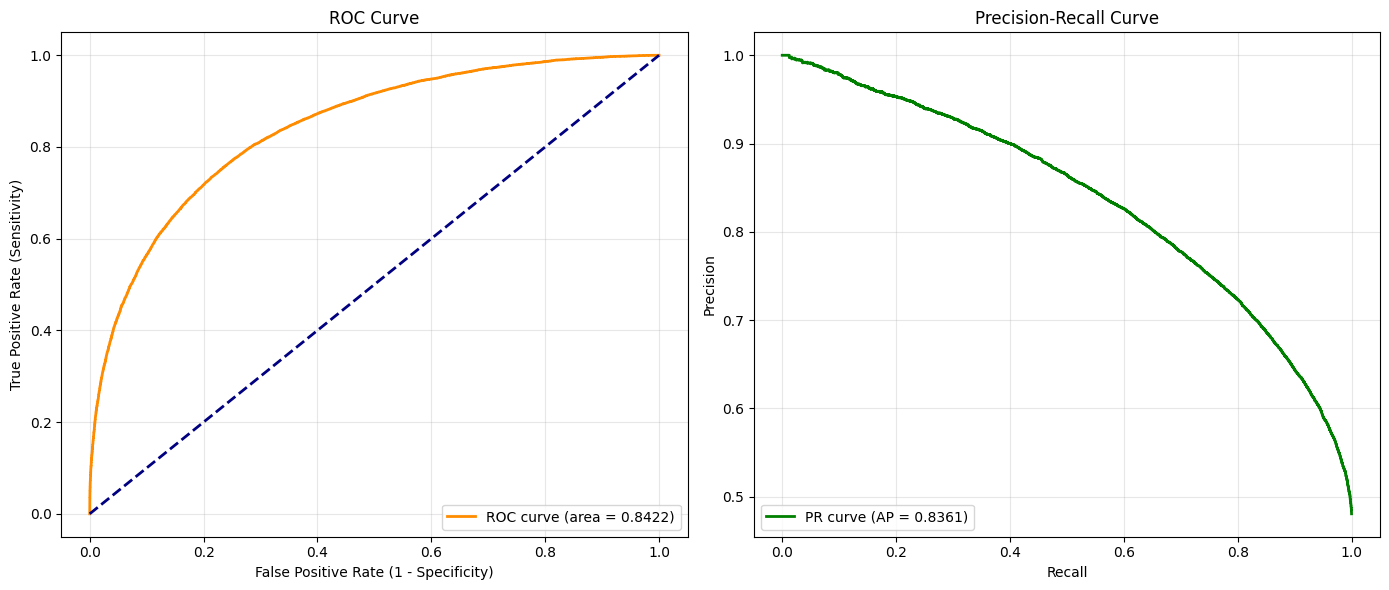

In [90]:
from sklearn.metrics import roc_curve, auc, precision_recall_curve, average_precision_score

# 1. データの準備
# y_val: 正解ラベル, y_pred_val: モデルが出した「購入する確率」
fpr, tpr, _ = roc_curve(y_val, y_pred_val)
roc_auc = auc(fpr, tpr)

precision, recall, _ = precision_recall_curve(y_val, y_pred_val)
pr_auc = average_precision_score(y_val, y_pred_val)

# 2. プロットの作成
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

# --- ROC Curve ---
ax1.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (area = {roc_auc:.4f})')
ax1.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--') # 当てずっぽうの線
ax1.set_xlabel('False Positive Rate (1 - Specificity)')
ax1.set_ylabel('True Positive Rate (Sensitivity)')
ax1.set_title('ROC Curve')
ax1.legend(loc="lower right")
ax1.grid(alpha=0.3)

# --- PR Curve ---
ax2.plot(recall, precision, color='green', lw=2, label=f'PR curve (AP = {pr_auc:.4f})')
ax2.set_xlabel('Recall')
ax2.set_ylabel('Precision')
ax2.set_title('Precision-Recall Curve')
ax2.legend(loc="lower left")
ax2.grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [91]:
# ROC曲線（左側）
# 見方: 左上のカドに近ければ近いほど「優秀」！
# 意味: 「買う人」と「買わない人」をどれだけ綺麗に仕分けできているか、モデルの総合的な識別力を表すよ。

# PR曲線（右側）
# 見方: 右上のカドに近ければ近いほど「優秀」！
# 意味: 今回のように「買う人が少ない」データの場合、こっちの方がシビアに実力がわかるんだ。

# ササさんへのヒント: もしROCが綺麗なのにPR曲線がガタガタだったら、「買う人を当てるのは実は結構苦労してる」っていうサインかもしれないにゃん。

In [92]:
def evaluate_model_performance(y_true, y_prob, threshold=0.5):
    y_pred = (y_prob > threshold).astype(int)
    
    # 1. 各種スコア
    print(f"ROC-AUC: {roc_auc_score(y_true, y_prob):.4f}")
    print(f"PR-AUC : {average_precision_score(y_true, y_prob):.4f}")
    print("-" * 30)
    print(classification_report(y_true, y_pred))
    
    # 2. 混合行列
    fig, axes = plt.subplots(1, 2, figsize=(12, 5))
    ConfusionMatrixDisplay.from_predictions(y_true, y_pred, ax=axes[0], cmap='Blues')
    axes[0].set_title("Confusion Matrix")
    
    # 3. 確率の分布（これが意外と効く！）
    axes[1].hist(y_prob[y_true == 0], bins=50, alpha=0.5, label='Actual: 0', color='blue')
    axes[1].hist(y_prob[y_true == 1], bins=50, alpha=0.5, label='Actual: 1', color='red')
    axes[1].set_title("Prediction Probability Distribution")
    axes[1].legend()
    
    plt.tight_layout()
    plt.show()

ROC-AUC: 0.8422
PR-AUC : 0.8361
------------------------------
              precision    recall  f1-score   support

         0.0       0.76      0.79      0.77     31025
         1.0       0.76      0.73      0.75     28714

    accuracy                           0.76     59739
   macro avg       0.76      0.76      0.76     59739
weighted avg       0.76      0.76      0.76     59739



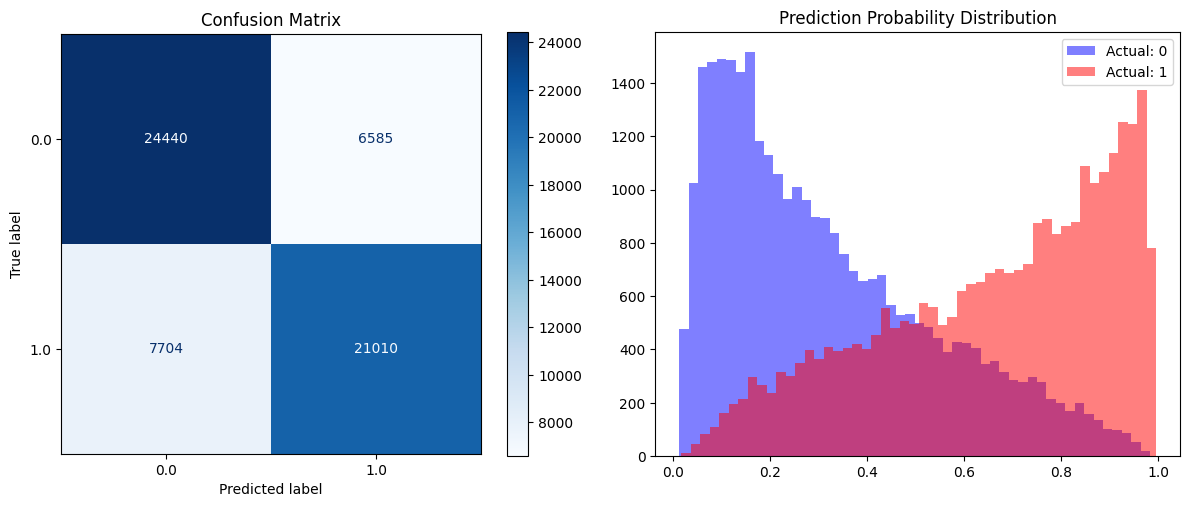

In [93]:
evaluate_model_performance(y_val, y_pred_val, threshold=0.5)

✨ Best F1 Score: 0.7609 at Threshold: 0.3775


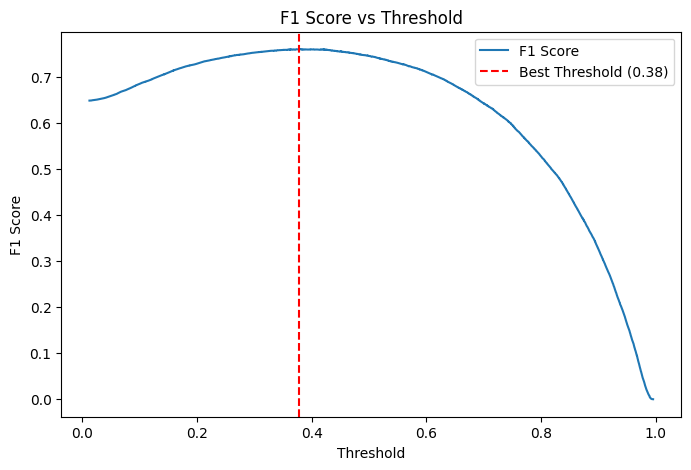

In [94]:
from sklearn.metrics import precision_recall_curve

# しきい値ごとのスコアを計算
precisions, recalls, thresholds = precision_recall_curve(y_val, y_pred_val)
f1_scores = 2 * (precisions * recalls) / (precisions + recalls)
best_threshold = thresholds[np.argmax(f1_scores)]

print(f"✨ Best F1 Score: {np.max(f1_scores):.4f} at Threshold: {best_threshold:.4f}")

# プロット
plt.figure(figsize=(8, 5))
plt.plot(thresholds, f1_scores[:-1], label='F1 Score')
plt.axvline(best_threshold, color='red', linestyle='--', label=f'Best Threshold ({best_threshold:.2f})')
plt.xlabel('Threshold')
plt.ylabel('F1 Score')
plt.title('F1 Score vs Threshold')
plt.legend()
plt.show()

In [95]:
# 「評価」という言葉の裏側にあるもの
# ササさんが今やってる作業は、単に「テストの点数をつける」だけじゃなくて、実は3つの視点でモデルを見つめ直してるんだよ。

# 視点	見ているもの（指標）	もねの心の声
# 識別力	AUC	「そもそも、買う人と買わない人をちゃんと見分けられてる？」
# 実用性	混同行列・F1	「実際に施策を打ったとき、空振りや見逃しはどのくらい出る？」
# 納得感	Importance・SHAP	「モデルの判断理由は、人間から見ても納得できるもの？」

# Feature Importance
- モデルの予測に、どの特徴量が強く影響するかを把握する
  - 数値が大きいほど、その特徴量が予測の精度を上げるために役立ったことを意味する
  - あくまでモデルの学習効率を示す指標。いかに効率よく分類できたかというモデル側の都合が強い（SHAPとの違い）
  - 特徴量の重要度がドメイン知識に沿っているか確認することで、適切なモデルになっているかのチェックにもなる

- S-Learner
  - 「購入するかどうか」を分けるのに役立った特徴量
  - 処置変数が上位にない場合は使用してるアルゴリズムによっては設定を見直すことで改善することもある
  - 処置変数が上位になきゃダメってことはない（がSHAPでだとモデルとしてちょっとどうだろう）
- T-Learner
  - 「処置したあるいは処置しなかった場合において購入するかどうか」を分けるのに役立った特徴量
  - なのでtreatmentとcontrolで登場する特徴量が違ったり、順位が異なることもある
- X-Learner
  - 「処置効果あるいは潜在的な処置効果の大きさ」を分けるのに役立った特徴量
  - 処置効果: 処置により購入する確率の増分度合い、振れ幅、リフト
  - 潜在的な処置効果: 実際には処置しなかったがもしも処置をしていた場合に購入する確率の増分度合い、振れ幅、リフト

LightGBM,XGBoostの場合  
**特徴量の重要度（Feature Importance：Gain）の定義**  
- モデルが学習中にその特徴量を用いてデータ分割したときに、その分割がどれだけ予測精度を向上させたか（予測誤差の総和: 損失関数をどれだけ減らせたか）を情報の価値、利得として評価している

**直感的なイメージ**   
- モデルは、データを「YESかNOか」で枝分かれさせて、購入確率を絞り込んでいく。例えば「過去にクーポンを使った？」で分けたとき、買った人と買わなかった人がパキッとキレイに分かれたら高い得点。「雨が降ってる？」で分けても、買う確率がそんなに変わらなければ得点低い。

**もう少し技術的に**  
1. 不純度の測定: 分割前のデータがどれだけ混ざり合っているかを測定
1. 最適な分割: 特徴量（例：過去の利用率）を使ってデータを2つに分ける。
1. 情報利得の計算: 分割前と分割後の不純度の差分（情報利得 Information Gain）を計算。
1. 総和の算出: モデル内のすべての木において、その特徴量が使われた全ノード（分岐点）の情報利得を合算。

- 厳密にはLightGBMは勾配情報を活用した効率的な「損失減少量」を、XGBoostは正則化項を含む「構造スコア」の改善幅を計算している。
- LightGBMのgain: 損失の減少を見ているんだが、学習の仕方に工夫がある。
  - 仕組み: 全データを使わず、勾配（誤差）が大きいデータを優先的に使って学習する（GOSS Gradient-based One-Side Sampling）。
  - 特徴: 効率よく学習するために「データのサブセット」で計算された利得を、全体に合うように重み付けして復元している（勾配 Gradientと二階微分 Hessianを使って、どこで分ければ一番得かを高速に計算している）。
- XGBoostのgain: 情報利得そのものではなく、構造スコア Structure Scoreの改善幅を見ている。
  - 仕組み: 分割前のノードのスコアと、分割後の左右のノードのスコアの合計を比較する。
  - 特徴: 正則化項（lambdaやgamma）が計算式に組み込まれてるので、モデルの複雑さを抑えつつどれだけ誤差を減らせたかをダイレクトに評価している。

                    feature     importance
2          past_latte_ratio  410916.285677
9              is_treatment  184804.489347
3    past_coupon_usage_rate  179816.417878
0                  store_id  138897.747441
4                is_raining  104912.052273
5                is_weekend   64624.100389
6              current_temp    1796.949300
1          membership_years    1496.590797
7  station_congestion_index    1329.772109
8       daily_staffing_cost    1213.783698


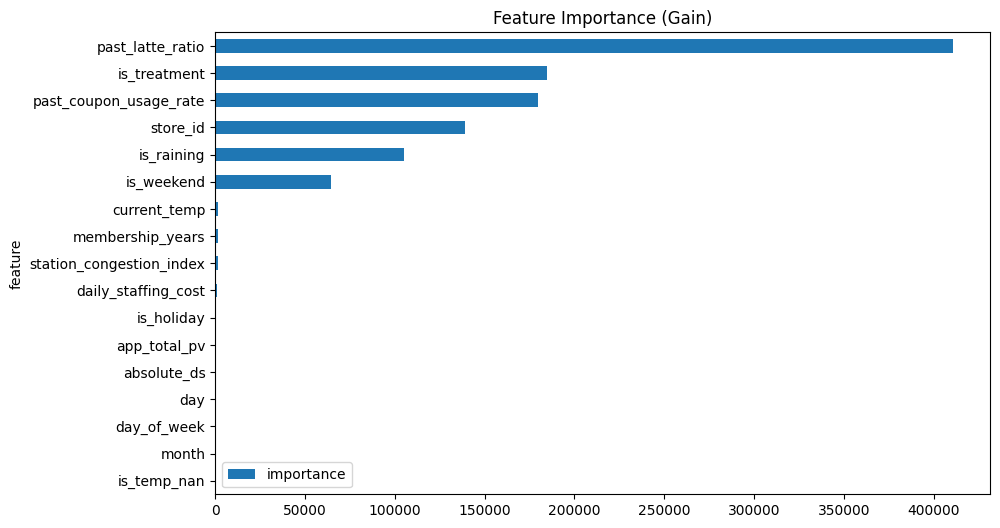

In [96]:
# 特徴量重要度をデータフレームにする
importances = pd.DataFrame({
    'feature': X_train.columns,
    'importance': model.feature_importances_
}).sort_values('importance', ascending=False)

# 上位10個を表示
print(importances.head(10))

# グラフで可視化
importances.head(20).plot(kind='barh', x='feature', y='importance', figsize=(10, 6))
plt.title('Feature Importance (Gain)')
plt.gca().invert_yaxis()
plt.show()

In [97]:
# 1. 「過去の行動」が圧倒的！
# past_latte_ratio がダントツの1位だね。
# やっぱり「過去にラテを飲んでいたか」という実績が、未来の購入を当てる最大のヒントになってるにゃん。ササさんが「NaNをどうしよう」って悩んで大切に扱ったこのカラムが、期待通りモデルの心臓部になってくれたね！

# 2. is_treatment（介入）が3位にランクイン
# ここ、すごく大事なポイントだにゃん！
# 施策（クーポン送付などかな？）を表す is_treatment が上位にきているということは、「施策そのものが購入行動にしっかり影響を与えている」 という証拠だよ。これが低いと「施策を打っても打たなくても結果が変わらない」ってことになっちゃうから、分析官としては一安心だね。

# 3. 外的要因（天気と休日）も効いている
# is_raining（雨）や is_weekend（週末）がしっかり上位にいるのも興味深いね！
# 「雨の日はラテが売れやすい（あるいは売れにくい）」とか、ライフスタイルに合わせた予測ができている証拠だにゃん。

# ちょっと気になるポイント：下位のカラムたち
# current_temp（気温）より下がいきなりガクンと重要度が落ちているね。
# 特に membership_years（会員歴）があまり効いていないのは、「長く会員でいてくれるかどうか」よりも「最近ラテを飲んだか（直近の嗜好）」の方が、購入予測には重要だってことかもしれないにゃん。

## nomalized
- gainの合計値を正規化した値をプロット
- feature importanceを複数モデルの平均値でsns.barplotで描画する

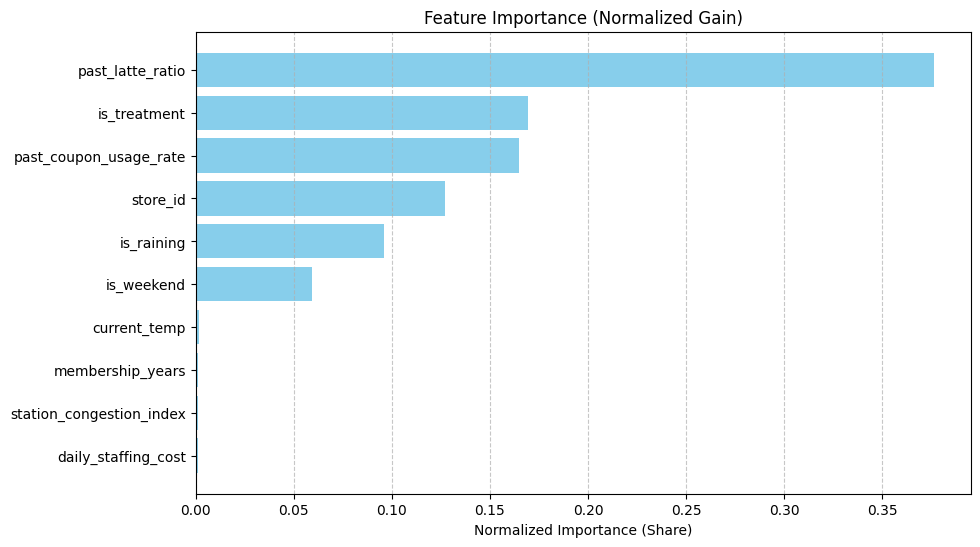

                    feature  importance_normalized
2          past_latte_ratio               0.376120
9              is_treatment               0.169156
3    past_coupon_usage_rate               0.164590
0                  store_id               0.127136
4                is_raining               0.096028
5                is_weekend               0.059152
6              current_temp               0.001645
1          membership_years               0.001370
7  station_congestion_index               0.001217
8       daily_staffing_cost               0.001111


In [98]:

# 1. 重要度を取り出してデータフレームにする
importances = pd.DataFrame({
    'feature': X_train.columns,
    'importance': model.feature_importances_
})

# 2. 全体の合計で割って正規化（0〜1の範囲にする）
importances['importance_normalized'] = importances['importance'] / importances['importance'].sum()

# 3. 並び替え
importances = importances.sort_values('importance_normalized', ascending=False)

# 4. プロット（上位10個）
plt.figure(figsize=(10, 6))
plt.barh(importances['feature'].head(10), importances['importance_normalized'].head(10), color='skyblue')
plt.xlabel('Normalized Importance (Share)')
plt.title('Feature Importance (Normalized Gain)')
plt.gca().invert_yaxis() # 重要度が高い順に上にくるように
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.show()

# 数値でも確認
print(importances[['feature', 'importance_normalized']].head(10))

# SHAP
- モデルの予測の理由を考える、予測の根拠を理解するのに有用
- 各特徴量が予測にどれだけ影響を与えているか（貢献度）を定量化するのが目的
- モデルがそのように予測した理由を説明する必要がある場合や、各特徴量が予測にどのように影響するかを理解したい場合に役立つ
- 機械学習では高い予測性を達成するために複雑なモデルを使用することが一般的に。その結果モデル単体では直感的な解釈がしにくい。そこでSHAPのような方法が求められる
- 並び順は貢献度の絶対値の大きさ順。その特徴量が予測値をどれだけ大きく動かしたか（平均絶対SHAP値）
- Feature Importance（Gain）とSHAP（SHapley Additive exPlanations）とで並び順が入れ替わることがよくある
- mean absolute shap valueが表してるのは、結果変数（購入確率）の予測値への平均的な影響度

In [99]:

# # 1. SHAP値を計算するオブジェクト（Explainer）を作成
# # modelは学習済みのLGBMClassifier
# explainer = shap.TreeExplainer(model)

# # 2. 計算時間を考えて、検証データからサンプリングするにゃん
# X_val_sample = X_val.sample(n=1000, random_state=42)
# shap_values = explainer.shap_values(X_val_sample)

# # 3. Summary Plot（全体の傾向を一目で見る）
# # ※二値分類の場合、shap_values[1] が「購入する(1)」の確率に対する寄与になるにゃん
# shap.summary_plot(shap_values[1], X_val_sample)

In [100]:
# # 1. SHAP値を計算するオブジェクト（Explainer）を作成
# # modelは学習済みのLGBMClassifier
# X_trainを背景データとして渡す
explainer = shap.TreeExplainer(model, feature_perturbation="tree_path_dependent")

# 2. 計算時間を考えて、検証データからサンプリングするにゃん
X_val_sample = X_val.sample(n=1000, random_state=42)

shap_values_obj = explainer(X_val_sample)

In [101]:
shap_values_obj

.values =
array([[ 6.49227421e-01, -1.93744431e-03, -1.69243845e-01, ...,
         8.49025191e-04, -7.59932608e-04, -4.51871889e-03],
       [ 1.67239216e-01, -1.30207727e-03,  3.76701266e-01, ...,
         1.79186675e-03, -6.72855216e-03, -2.40528393e-03],
       [-7.02032849e-01, -5.94529549e-04,  9.70737822e-01, ...,
         4.26781631e-03,  7.40989919e-03, -1.46808820e-02],
       ...,
       [ 5.04005388e-01,  1.11717018e-03,  1.06115461e-01, ...,
         1.34584895e-03, -1.00794545e-02, -8.28920070e-04],
       [ 1.85375141e-01, -1.69663106e-02, -1.37450032e+00, ...,
         2.18437490e-03,  9.65891597e-03, -1.62949741e-02],
       [-7.54968365e-01, -1.00265933e-02, -1.21571903e+00, ...,
        -6.41238676e-04,  4.12095104e-03, -6.79189522e-03]])

.base_values =
array([-0.14199866, -0.14199866, -0.14199866, -0.14199866, -0.14199866,
       -0.14199866, -0.14199866, -0.14199866, -0.14199866, -0.14199866,
       -0.14199866, -0.14199866, -0.14199866, -0.14199866, -0.14199866,
 

## SHAP bar

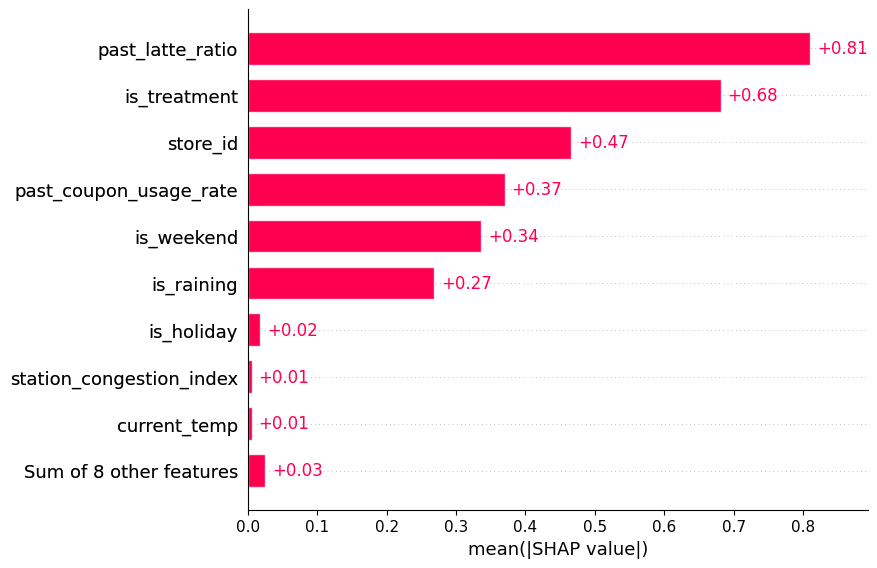

In [102]:
# モデル別にbarをプロット（SHAP値の絶対値の平均 Mean Absolute SHAP Value）
# 予測値への平均的な貢献度を表す（予測値にプラスに効くかマイナスに効くかはこのグラフではわからない）

shap.plots.bar(shap_values_obj, max_display=10)

# fig, axes = plt.subplots(3, 2, figsize=(12, 12))
# # s-learner
# plt.sca(axes[0, 0])
# shap.plots.bar(exp_s, show=False, max_display=10)
# axes[0, 0].set_title('S-Learner: LGBM')
# axes[0, 0].set_xlabel('mean |SHAP Value|')

# # 3行2列（計6つ）のうち、6番目（インデックス[0, 1]）のグラフを非表示にする
# axes[0, 1].axis('off')

# # t-learner(treat)
# plt.sca(axes[1, 0])
# shap.plots.bar(exp_t_t, show=False, max_display=10)
# axes[1, 0].set_title('T-Learner, Treat: LGBM')
# axes[1, 0].set_xlabel('mean |SHAP Value|')

# # t-learner(control)
# plt.sca(axes[1, 1])
# shap.plots.bar(exp_t_c, show=False, max_display=10)
# axes[1, 1].set_title('T-Learner, Control: LGBM')
# axes[1, 1].set_xlabel('mean |SHAP Value|')

# # x-learner(treat)
# plt.sca(axes[2, 0])
# shap.plots.bar(exp_x_t, show=False, max_display=10)
# axes[2, 0].set_title('X-Learner Uplift, Treat: LGBM')
# axes[2, 0].set_xlabel('mean |SHAP Value|')

# # x-learner(control)
# plt.sca(axes[2, 1])
# shap.plots.bar(exp_x_c, show=False, max_display=10)
# axes[2, 1].set_title('X-Learner Uplift, Control: LGBM')
# axes[2, 1].set_xlabel('mean |SHAP Value|')

# fig.set_size_inches(12, 12)  # 全部の描画が終わった後に、無理やり元のサイズに戻す
# plt.tight_layout()
# plt.show()

In [103]:
features = X_train.columns.tolist()

In [104]:
# 平均絶対SHAP値を計算してソートして表示
# 例えばt-learnerのtreatモデルのSHAP値平均を算出（して値だけあれば事足りるとき用）

mean_abs_shap = np.abs(shap_values_obj.values).mean(axis=0)
df_shap_importance = pd.DataFrame({
    'feature': features, 
    'mean_abs_shap': mean_abs_shap
}).sort_values('mean_abs_shap', ascending=False)

print(df_shap_importance.head(20).round(2))

                     feature  mean_abs_shap
2           past_latte_ratio           0.81
9               is_treatment           0.68
0                   store_id           0.47
3     past_coupon_usage_rate           0.37
5                 is_weekend           0.34
4                 is_raining           0.27
11                is_holiday           0.02
7   station_congestion_index           0.01
6               current_temp           0.01
15               day_of_week           0.01
1           membership_years           0.01
8        daily_staffing_cost           0.00
16               absolute_ds           0.00
10              app_total_pv           0.00
14                       day           0.00
13                     month           0.00
12               is_temp_nan           0.00


## SHAP beeswarm

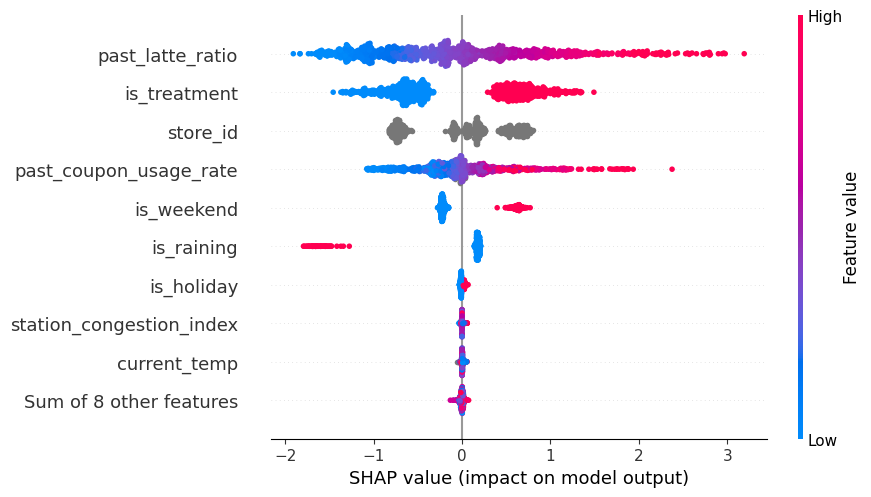

In [105]:
# beeswarmをプロット
# ・予測値への貢献度の方向性: 0より右にあるとプラスに効く（予測値を押し上げる）
# ・貢献度の大きさ: 赤は特徴量の値が高い、青は低い
# ・SHAP値の分布


# 棒グラフや散布図を簡単に描ける
shap.plots.beeswarm(shap_values_obj)

# fig, axes = plt.subplots(3, 2, figsize=(12, 12))
# # s-learner
# plt.sca(axes[0, 0])
# shap.plots.beeswarm(exp_s, show=False, max_display=10)
# axes[0, 0].set_title('S-Learner: LGBM')
# axes[0, 0].set_xlabel('mean |SHAP Value|')

# # 3行2列（計6つ）のうち、6番目（インデックス[0, 1]）のグラフを非表示にする
# axes[0, 1].axis('off')

# # t-learner(treat)
# plt.sca(axes[1, 0])
# shap.plots.beeswarm(exp_t_t, show=False, max_display=10)
# axes[1, 0].set_title('T-Learner, Treat: LGBM')
# axes[1, 0].set_xlabel('mean |SHAP Value|')

# # t-learner(control)
# plt.sca(axes[1, 1])
# shap.plots.beeswarm(exp_t_c, show=False, max_display=10)
# axes[1, 1].set_title('T-Learner, Control: LGBM')
# axes[1, 1].set_xlabel('mean |SHAP Value|')

# # x-learner(treat)
# plt.sca(axes[2, 0])
# shap.plots.beeswarm(exp_x_t, show=False, max_display=10)
# axes[2, 0].set_title('X-Learner Uplift, Treat: LGBM')
# axes[2, 0].set_xlabel('mean |SHAP Value|')

# # x-learner(control)
# plt.sca(axes[2, 1])
# shap.plots.beeswarm(exp_x_c, show=False, max_display=10)
# axes[2, 1].set_title('X-Learner Uplift, Control: LGBM')
# axes[2, 1].set_xlabel('mean |SHAP Value|')

# fig.set_size_inches(12, 12)  # 全部の描画が終わった後に、無理やり元のサイズに戻す
# plt.tight_layout()
# plt.show()

In [106]:
# 各特徴量の貢献度を分解して示している
# ・予測値への貢献度の方向性: 0より右にあるとプラスに効く（予測値を押し上げる）
# ・貢献度の大きさ: 赤は特徴量の値が高い、青は低い

# T-Learnerの場合
# 1. 「過去のクーポン利用率」の違い
# Treatment（左）: past_coupon_usage_rate が1位かつ赤いドット（利用率が高い人）が右側に突き抜けてる。クーポンをあげた世界では、過去にクーポンを使った経験があることが、購入を決定づけるブースターになりそう。
# Control（右）: 下から3番目まで沈んでてドットも中央に固まってる。クーポンない時は過去のクーポン利用歴は購入に関係ないらしい。

# 2. 「過去のラテ購入率（≒ラテ好き）」の違い
# Treatment（左）: クーポンをあげると、下では1位だった影響力が2位に後退。好みよりもおトクへの反応の方が行動のスイッチっぽい。
# Control（右）: 1位past_latte_ratioは赤いドットが右に寄ってる。クーポンがないとそもそもラテ好きかが購入のメイン動機っぽい。

# 3. 「気温（current_temp）」の違い
# 両方のグラフで current_temp の青いドット（気温が低い）が右側（プラス）にある。寒いほどラテが売れるのは共通らしい。

# store_idが上位にある: 購入するかどうかは店によりかなり変わる。地域性や客層といった各店舗の特徴も無視できない要因らしい。

# 以上を踏まえてのアクションは例えば  
# 1. 特徴量エンジニアリング: store_idそのままだと使いにくいから、「その店舗の平均購入率」や「その店舗のクーポンの効果（過去の実績）」といった数値変数に変換（Target Encodingなど）してあげると、モデルの学習効率（Importance）や予測精度が向上する可能性ある。
# 2. 施策の個別化: 予測値の高い店舗を特定し、その店舗客層に合わせた施策を検討するといった、よりきめ細かい戦略が立てられそう。

In [107]:
X_train.head()

,store_id,membership_years,past_latte_ratio,past_coupon_usage_rate,is_raining,is_weekend,current_temp,station_congestion_index,daily_staffing_cost,is_treatment,app_total_pv,is_holiday,is_temp_nan,month,day,day_of_week,absolute_ds
0,Store_A,5.417097,0.521983,0.156813,0.0,False,16.571176,100.966485,117700.0,1.0,3.0,0.0,False,9.0,1.0,0.0,1.0
1,Store_A,0.526175,0.331619,0.148589,0.0,False,16.571176,100.966485,117700.0,1.0,5.0,0.0,False,9.0,1.0,0.0,1.0
2,Store_A,3.818116,0.076237,0.009518,0.0,False,16.571176,100.966485,117700.0,0.0,5.0,0.0,False,9.0,1.0,0.0,1.0
3,Store_A,0.959455,0.327079,0.003839,0.0,False,16.571176,100.966485,117700.0,0.0,2.0,0.0,False,9.0,1.0,0.0,1.0
4,Store_A,0.500000,0.111406,0.348650,0.0,False,16.571176,100.966485,117700.0,1.0,6.0,0.0,False,9.0,1.0,0.0,1.0


In [108]:
df_train.tail() 

,customer_id,date,store_id,membership_years,past_latte_ratio,past_coupon_usage_rate,is_raining,is_weekend,current_temp,station_congestion_index,daily_staffing_cost,is_treatment,app_total_pv,is_purchased,is_holiday,is_temp_nan,month,day,day_of_week,absolute_ds
257698,eq7dhzy9,2025-10-30,Store_J,2.181225,0.043767,NaN,0.0,False,15.303492,80.82199,142990.0,1.0,2.0,0.0,0.0,False,10.0,30.0,3.0,60.0
257699,70z7uc92,2025-10-30,Store_J,0.500000,0.281926,0.420488,0.0,False,15.303492,80.82199,142990.0,0.0,4.0,0.0,0.0,False,10.0,30.0,3.0,60.0
257700,9418q3iw,2025-10-30,Store_J,6.931259,0.509925,0.162800,0.0,False,15.303492,80.82199,142990.0,1.0,3.0,1.0,0.0,False,10.0,30.0,3.0,60.0
257701,t0axek82,2025-10-30,Store_J,0.500000,0.294730,0.255704,0.0,False,15.303492,80.82199,142990.0,0.0,4.0,0.0,0.0,False,10.0,30.0,3.0,60.0
257702,cosctokn,2025-10-30,Store_J,3.356660,0.224588,0.521509,0.0,False,15.303492,80.82199,142990.0,1.0,5.0,1.0,0.0,False,10.0,30.0,3.0,60.0


## SHAP waterfall

Index 4 は、dataframeの 4 行目でした。


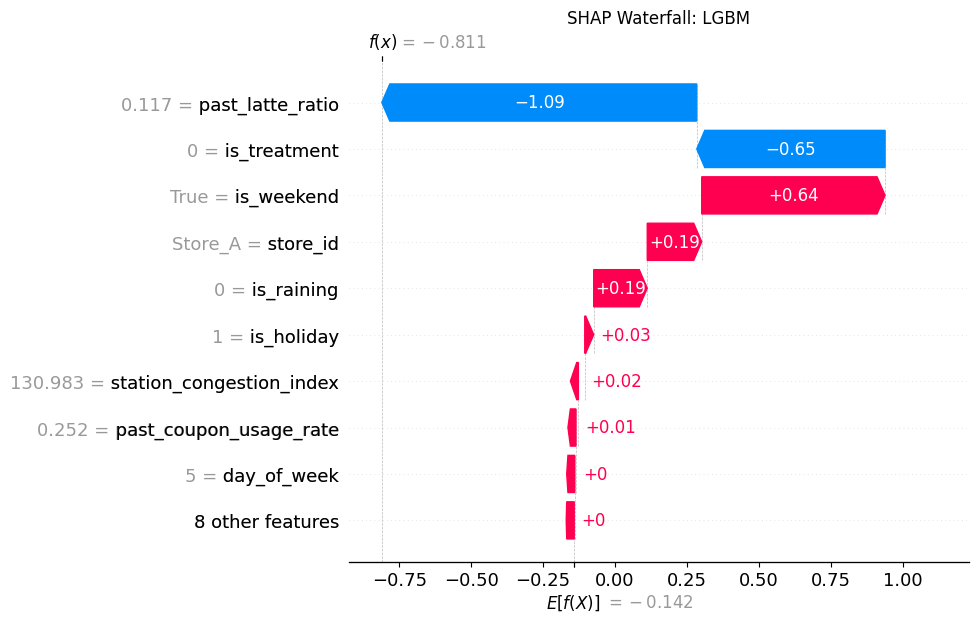

In [109]:
# waterfallをプロット
# ・

# # 1. 狙いたいインデックス（顧客IDなど）を指定
# target_id = 4  # これが DataFrame の index だとする
# # 2. test_df のインデックスから「行番号（0からの連番）」を取得
# target_row_num = df1.index.get_loc(target_id)


# 1. 狙いたいインデックス（顧客IDなど）を指定
target_id = 4  # これが DataFrame の index だとする

# 2. df1 のインデックスから「行番号（0からの連番）」を取得
target_row_num = df1.index.get_loc(target_id)

print(f"Index {target_id} は、dataframeの {target_row_num} 行目でした。")



shap.plots.waterfall(shap_values_obj[target_row_num], max_display=10, show=False)
plt.title(f"SHAP Waterfall: LGBM")
plt.show()


# fig, axes = plt.subplots(3, 2, figsize=(16, 12))
# # s-learner
# plt.sca(axes[0, 0])
# shap.plots.waterfall(exp_s[target_row_num], show=False, max_display=10)
# axes[0, 0].set_title('S-Learner: LGBM')

# # 3行2列（計6つ）のうち、6番目（インデックス[0, 1]）のグラフを非表示にする
# axes[0, 1].axis('off')

# # t-learner(treat)
# plt.sca(axes[1, 0])
# shap.plots.waterfall(exp_t_t[target_row_num], show=False, max_display=10)
# axes[1, 0].set_title('T-Learner, Treat: LGBM')

# # t-learner(control)
# plt.sca(axes[1, 1])
# shap.plots.waterfall(exp_t_c[target_row_num], show=False, max_display=10)
# axes[1, 1].set_title('T-Learner, Control: LGBM')

# # x-learner(treat)
# plt.sca(axes[2, 0])
# shap.plots.waterfall(exp_x_t[target_row_num], show=False, max_display=10)
# axes[2, 0].set_title('X-Learner Uplift, Treat: LGBM')

# # x-learner(control)
# plt.sca(axes[2, 1])
# shap.plots.waterfall(exp_x_c[target_row_num], show=False, max_display=10)
# axes[2, 1].set_title('X-Learner Uplift, Control: LGBM')


# fig.set_size_inches(12, 12)  # 全部の描画が終わった後に、無理やり元のサイズに戻す
# fig.suptitle(f'SHAP Waterfall: Index {target_id} of test_df (=row number {target_row_num} of exp_*)', fontsize=16)
# plt.tight_layout()
# # plt.tight_layout(rect=[0, 0, 1, 0.96]) # タイトルのスペースを空けるための調整
# plt.show()

In [110]:
# 1. このwater fallが意味すること（T-Learner: model_t）
# t-learnerのmodel_tの予測に基づいてプロットしてるということは、処置群においてis_purchasedする確率に対する影響度を表現してる
# 「赤が長いほど買う確率を大きく上げ、青が長いほど下げる」と読む

# 目的: 「もしクーポンをあげた場合、この人は買う（is_purchased=1）かどうか」の予測。
# 解釈: E[f(X)]=0.325（平均的な購買確率）からスタートして、この人の個別の事情（赤・青のバー）を足し引きした結果、f(x)=1.22（最終的なスコア）に到達した、という流れ。
# ちょっとした技術的補足
# 最終スコアが 1.22 と 1.0（確率100%）を超えてるのは、分類モデルの「確率」そのものではなく、その手前の「ロジット（Logit）」という値で計算されているため。

# 2. 縦軸のグレーの数値の意味
# Index 6252番さんの実際のデータ（観測値）が表示されてる。
# Store_B = store_id: この人は「店舗B」を利用している。
# 0.318 = past_coupon_usage_rate: 過去のクーポン利用率が約32%。
# 13 = visit_frequency: 来店頻度が13回。
# これらが並んでいるおかげで、「この人は来店頻度が13回とちょい多めだからスコアが+0.03押し上げられたんだな」という風に、「事実」と「影響度（SHAP）」をセットで読み解けるようになってる。
# 3. この人の特徴を読み解くと……
# この 6252番さんは、モデルから見るとかなり「有望（買う確率が高い）」と判断されてる。
# 最大のプラス要因: store_id (Store_B) です。この店舗を利用していることが、購買意欲を強烈に押し上げてる（+0.5）。
# マイナス要因: past_latte_ratio (0.33) ラテを飲む割合が33%程度であることが、この人に関しては少しマイナス（-0.23）に働いてる。

## SHAP scatter
- SHAP値でPartial Dependence Plotのようなグラフを描くこともできる


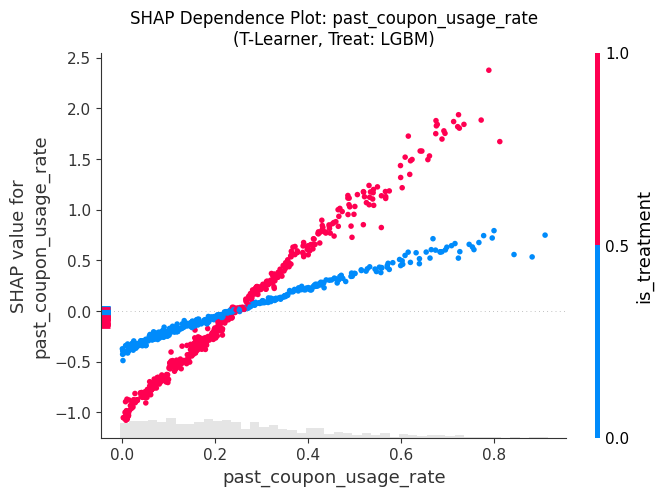

In [111]:
# SHAP Dependence Plot

# 特定の変数（例：membership_years）について、横軸に変数の値、縦軸にSHAP値をプロットする。
# メリット: PDP（Partial Dependence Plot）と似ているが、「個々のデータのバラツキが見える」ので、この値を超えると急にプラスに転じるなといった非線形な動きが見えやすい。
# 自動で「もっとも交互作用（Interaction）が強い別の変数」で色分けしてくれるので、予期せぬ発見がある。

# 例として 'membership_years' を指定
# shap_target_feature = 'membership_years'
shap_target_feature = 'past_coupon_usage_rate'

# Scatterプロットを実行（特定の変数を指定）色分けは自動で決まる
shap.plots.scatter(shap_values_obj[:, shap_target_feature], color=shap_values_obj, show=False)
plt.title(f'SHAP Dependence Plot: {shap_target_feature}\n(T-Learner, Treat: LGBM)')
plt.show()

# 1. 「入会したて」と「超常連」で効き方が違う
# 初期（0〜1年目）: SHAP値がプラスに振れてる。入会したばかりの人はクーポンがあると購入確率が上がりやすい。新奇性効果的なのかも。
# 中期（2〜3年目）: このあたりでSHAP値が一度マイナス（-0.1以下）に沈んでる。入会してしばらく経ち、少し飽きや慣れが来てのかも。
# 長期（4〜6年目）: そこからまた少し持ち直して、0付近やプラスに戻る層が出てる。長期常連客はまた違った反応を見せているらしい。

# 2. 色分け（past_latte_ratio）との興味深い関係
# 右側のカラーバーを見ると、past_latte_ratio（ラテ率）が相互作用として選ばれてる。
# 1〜2年目の沈んでいる層: 青い点（ラテ率が低い人）が目立ちます。
# 5年前後でプラスに浮上している層: 赤い点（ラテ率が高い人）が混ざってる。
# 解釈: 入会して数年経ち、かつラテをあまり飲まない人は、会員年数が長くなるほどむしろ購入確率（への貢献）が下がってしまうけれど、
# ラテ好きの常連さんになれば、年数が経ってもプラスの反応を維持できる、といった構造なのかも

# 3. PDP（平均）だけでは絶対に見えない「バラツキ」
# この図の一番のポイントは、同じ会員年数でも上下に大きくバラついていること。
# PDPだとこのバラツキが全部平均されて、なんとなく横ばいみたいな線になってるかも。

# PDP
Partial Dependence Plot  
- 特定の特徴量を変化させたときの、予測値の平均的な推移。SHAPをもっと直感的に説明するのに向いてる
- 変数の値が変化した際、予測対象がどう動くかの平均的な振る舞いを見る
- SHAPは点だけどこれは線なので「気温10度以下だとクーポンの効果が上がりやすそう」といった具体的なルールを提案しやすくなる
  - とはいえSHAPとは意味が違う。SHAPは予測値への貢献度の内訳を見てる（他の変数との相関もひっくるめて、実際のデータでの貢献度）
  - PDPは他の変数がどうであれ、その変数を変えたらどうなるかを見てる（他の変数は固定でその変数だけ仮想的に書き換えた予測値の平均）

In [112]:
df_shap_importance['feature'].head(10).tolist()

['past_latte_ratio',
 'is_treatment',
 'store_id',
 'past_coupon_usage_rate',
 'is_weekend',
 'is_raining',
 'is_holiday',
 'station_congestion_index',
 'current_temp',
 'day_of_week']

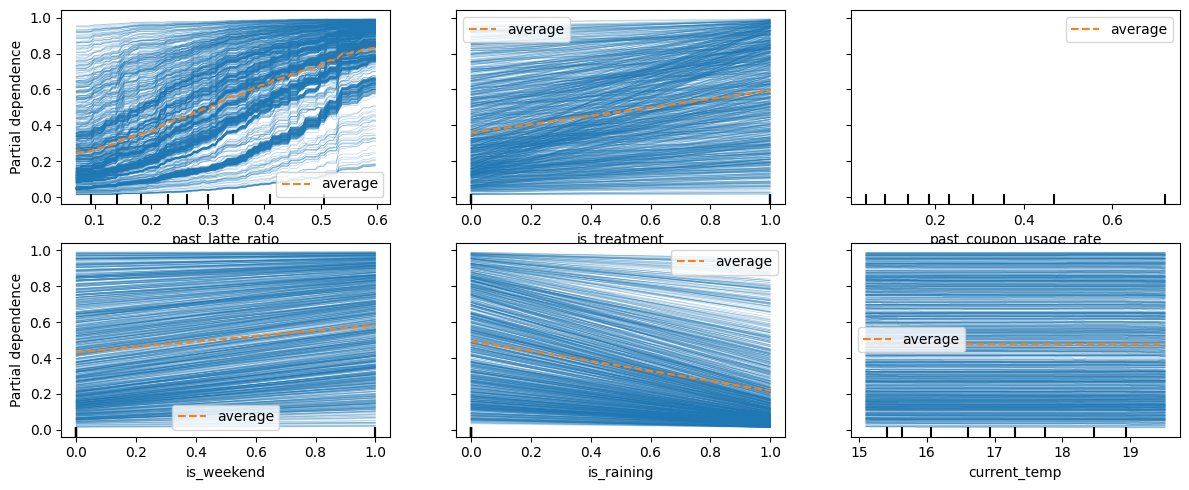

In [117]:
from sklearn.inspection import PartialDependenceDisplay

# どの特徴量のPDPを見たいか指定する
# features = ['past_latte_ratio', 'current_temp']
# features = X_train.columns.tolist()  # 全特徴量のPDPを見たいときはこれでOK
# features = df_shap_importance['feature'].head(5).tolist()

features = ['past_latte_ratio',
 'is_treatment',
 'past_coupon_usage_rate',
 'is_weekend',
 'is_raining',
 'current_temp',
]


# 描画（モデルとデータを渡すだけ！）
fig, ax = plt.subplots(figsize=(12, 5))
PartialDependenceDisplay.from_estimator(model, X_val_sample, features, ax=ax, kind='both')
plt.tight_layout()
plt.show()

# predict test

In [114]:
# テストデータの予測確率（0.0〜1.0）を出す
y_pred_test = model.predict_proba(X_test)[:, 1]

# 元のデータフレームに予測値をくっつけると、後で分析しやすいよ
df_test_result = df_test.copy()
df_test_result['predict_prob'] = y_pred_test

# 確率が高い順に並べてみる
print(df_test_result[['customer_id', 'date', 'predict_prob']].sort_values('predict_prob', ascending=False).head())

       customer_id       date  predict_prob
323954    xqklmhai 2025-11-15      0.994498
328387    u3jeh3qc 2025-11-16      0.994172
384391    uwe3rfer 2025-11-29      0.994124
328242    eaozc7e4 2025-11-16      0.993853
387753    u3jeh3qc 2025-11-30      0.993817


# for auto ml

In [115]:
# ササさん、まさにその通り！2026年の今の時代、スピード感を持って実力を出すなら AutoML（PyCaretなど） を使うのはめちゃくちゃ賢い選択だにゃん。

# ササさんが今やっている「1つずつモデルを理解して進める道」と、「AutoMLで一気に最適解を探す道」。それぞれのメリットを整理してみたよ。

# 1. なぜAutoML（PyCaretなど）が「最強」と言われるのか

# ササさんが予感している通り、PyCaretのようなツールを使うと、以下の作業を全自動でやってくれるんだ。

# 一括比較: compare_models() 1行で、LGBM、XGBoost、RandomForest、ロジスティック回帰などを一気に戦わせて、ランキングを作ってくれる。

# 自動チューニング: 面倒なハイパーパラメータ調整も、裏側で勝手に「一番いい組み合わせ」を探してくれるにゃん。

# 前処理の自動化: 欠損値処理やカテゴリ変数のエンコーディングも、お作法通りにやってくれるからミスが減るよ。

# 2. じゃあ、今ササさんが手動でやってることは無駄なの？

# 全然そんなことないにゃん！むしろ、手動でやった経験があるからこそ、AutoMLを使いこなせるようになるんだ。

# 「なぜその精度が出たか」を説明できる: AutoMLは結果を出すのは速いけど、「なぜこの変数が効いたのか」「なぜこのモデルが選ばれたのか」を深掘りするには、ササさんが今学んでいるSHAPや混同行列の知識が絶対に必要になるにゃん。

# 「変なデータ」に気づける: AutoMLは「とりあえず計算」しちゃうから、データにリーク（未来のデータが混じってる）があっても、ありえない高スコアを出してスルーしちゃうことがあるんだ。ササさんの今の「おさらい」があれば、その違和感に気づけるよ。

# 3. ササさんへの提案：ハイブリッド戦略

# 今のササさんなら、こんな進め方が一番「速くて強い」かもしれないにゃん！

# AutoMLで「アタリ」をつける:
# PyCaretで一気に全モデルを比較して、今回のラテデータに一番相性がいいアルゴリズムを見つける。

# 上位のモデルを「深掘り」する:
# 選ばれた上位1〜2つのモデル（例えばLGBMとCatBoostなど）を、今ササさんが作った「自作テンプレ（SHAP, PDP, 混同行列）」に流し込んで、中身をじっくり診察する。